In [5]:
# 0. Environment Setup and Global Configuration
import sys
import subprocess
import importlib.util
import random
import warnings
from pathlib import Path

OPTIONAL_PACKAGES = {
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "shap": "shap",
    "imbalanced-learn": "imblearn"
}

def install_if_missing(package_name, import_name):
    """
    Install a package only if its import module is unavailable.
    This avoids unnecessary re-installation during repeated notebook runs.
    """
    if importlib.util.find_spec(import_name) is None:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package_name],
            check=True
        )

for package_name, import_name in OPTIONAL_PACKAGES.items():
    install_if_missing(package_name, import_name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

import joblib

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# 1. Load local CSV files

DATA_DIR = Path("/content")

TABLE_FILES = {
    "transactions": "transactions",
    "customers": "customers",
    "products": "products",
    "behavior": "behavior"
}

def find_csv(stem, data_dir=DATA_DIR):
    """Find the most appropriate CSV file for a given table name."""
    data_dir = Path(data_dir)

    exact_matches = sorted(set(data_dir.rglob(f"{stem}.csv")))
    prefix_matches = sorted(set(data_dir.rglob(f"{stem}*.csv")))

    if exact_matches:
        return exact_matches[0]

    if prefix_matches:
        return prefix_matches[0]

    available_csvs = sorted([p.name for p in data_dir.rglob("*.csv")])
    raise FileNotFoundError(
        f"Cannot find a CSV file starting with '{stem}' under {data_dir}. "
        f"Available CSV files include: {available_csvs[:10]}"
    )

paths = {table: find_csv(stem) for table, stem in TABLE_FILES.items()}

print("Resolved file paths:")
for table, path in paths.items():
    print(f"{table}: {path}")

dataframes = {
    table: pd.read_csv(path)
    for table, path in paths.items()
}

transactions = dataframes["transactions"]
customers = dataframes["customers"]
products = dataframes["products"]
behavior = dataframes["behavior"]

print("\nDataset dimensions:")
for table, df in dataframes.items():
    print(f"{table}: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

print("\nColumn overview:")
for table, df in dataframes.items():
    print(f"\n{table}:")
    print(list(df.columns))

required_columns = {
    "transactions": {"customer_id", "product_id", "fraud_label"},
    "customers": {"customer_id"},
    "products": {"product_id"},
    "behavior": {"customer_id"}
}

for table, required_cols in required_columns.items():
    missing_cols = required_cols - set(dataframes[table].columns)
    if missing_cols:
        raise ValueError(f"{table} is missing required columns: {missing_cols}")

print("\nAll required key columns are present.")

Resolved file paths:
transactions: /content/transactions.csv
customers: /content/customers.csv
products: /content/products.csv
behavior: /content/behavior.csv

Dataset dimensions:
transactions: 150,000 rows × 10 columns
customers: 25,000 rows × 8 columns
products: 2,000 rows × 5 columns
behavior: 25,000 rows × 8 columns

Column overview:

transactions:
['transaction_id', 'customer_id', 'product_id', 'order_date', 'order_value', 'payment_method', 'device_type', 'discount_applied', 'shipping_delay_days', 'fraud_label']

customers:
['customer_id', 'age', 'gender', 'country', 'registration_date', 'loyalty_score', 'lifetime_value', 'churn_label']

products:
['product_id', 'category', 'price', 'margin_percentage', 'popularity_score']

behavior:
['customer_id', 'avg_session_time', 'pages_per_session', 'cart_abandon_rate', 'return_rate', 'support_tickets', 'review_score', 'behavior_churn_signal']

All required key columns are present.


In [3]:
# 2. Inspect source tables and audit basic data quality

tables = {
    "transactions": transactions,
    "customers": customers,
    "products": products,
    "behavior": behavior
}

table_summary = []

for table_name, df in tables.items():
    table_summary.append({
        "table": table_name,
        "n_rows": df.shape[0],
        "n_columns": df.shape[1],
        "duplicate_rows": df.duplicated().sum(),
        "total_missing_values": df.isna().sum().sum(),
        "missing_value_rate": df.isna().sum().sum() / (df.shape[0] * df.shape[1])
    })

table_summary = pd.DataFrame(table_summary)

display(table_summary)

for table_name, df in tables.items():
    print(f"\n{table_name.upper()} | shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

    column_audit = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "n_unique": df.nunique(dropna=True)
    }).reset_index().rename(columns={"index": "column"})

    display(column_audit)

    print("First five rows:")
    display(df.head())

key_checks = {
    "transactions.transaction_id": (transactions, "transaction_id"),
    "customers.customer_id": (customers, "customer_id"),
    "products.product_id": (products, "product_id"),
    "behavior.customer_id": (behavior, "customer_id")
}

key_summary = []

for key_name, (df, key_col) in key_checks.items():
    key_summary.append({
        "key": key_name,
        "n_rows": len(df),
        "n_unique_keys": df[key_col].nunique(dropna=True),
        "missing_keys": df[key_col].isna().sum(),
        "duplicate_keys": df[key_col].duplicated().sum()
    })

key_summary = pd.DataFrame(key_summary)

display(key_summary)

target_col = "fraud_label"

if target_col not in transactions.columns:
    raise ValueError(f"Target column '{target_col}' is missing from the transactions table.")

target_values = sorted(transactions[target_col].dropna().unique())

if set(target_values).issubset({0, 1}):
    fraud_distribution = transactions[target_col].value_counts().sort_index()
    fraud_distribution_pct = transactions[target_col].value_counts(normalize=True).sort_index()

    fraud_summary = pd.DataFrame({
        "count": fraud_distribution,
        "percentage": fraud_distribution_pct
    })

    display(fraud_summary)

    fraud_rate = transactions[target_col].mean()
    print(f"Fraud rate: {fraud_rate:.4%}")
else:
    print(f"Unexpected target values found in {target_col}: {target_values}")

,table,n_rows,n_columns,duplicate_rows,total_missing_values,missing_value_rate
0,transactions,150000,10,0,0,0.0000
1,customers,25000,8,0,0,0.0000
2,products,2000,5,0,0,0.0000
3,behavior,25000,8,0,0,0.0000



TRANSACTIONS | shape: 150,000 rows × 10 columns


,column,dtype,missing_count,missing_rate,n_unique
0,transaction_id,object,0,0.0000,150000
1,customer_id,object,0,0.0000,24938
2,product_id,object,0,0.0000,2000
3,order_date,object,0,0.0000,2001
4,order_value,float64,0,0.0000,50662
5,payment_method,object,0,0.0000,5
6,device_type,object,0,0.0000,3
7,discount_applied,float64,0,0.0000,51
8,shipping_delay_days,int64,0,0.0000,11
9,fraud_label,int64,0,0.0000,2


First five rows:


,transaction_id,customer_id,product_id,order_date,order_value,payment_method,device_type,discount_applied,shipping_delay_days,fraud_label
0,TXN0000001,CUST020953,PROD00229,2019-02-21,753.0800,Debit Card,Mobile,0.1900,4,0
1,TXN0000002,CUST003359,PROD01386,2023-02-25,9.2700,Credit Card,Tablet,0.4800,8,0
2,TXN0000003,CUST000977,PROD00192,2020-03-23,393.1100,Crypto,Tablet,0.3700,3,1
3,TXN0000004,CUST006516,PROD01467,2022-08-23,121.8300,UPI,Mobile,0.3000,8,0
4,TXN0000005,CUST009116,PROD01658,2023-11-16,826.5900,Debit Card,Tablet,0.0800,0,0


...

First five rows:


,customer_id,avg_session_time,pages_per_session,cart_abandon_rate,return_rate,support_tickets,review_score,behavior_churn_signal
0,CUST000001,8.1200,21,0.9500,0.3700,1,3.3900,1
1,CUST000002,3.9600,9,0.1600,0.0300,3,4.4600,1
2,CUST000003,12.4200,24,0.7100,0.0100,1,4.8800,0
3,CUST000004,16.8200,18,0.2100,0.0900,1,1.7300,0
4,CUST000005,6.7800,2,0.5200,0.2200,0,2.1600,1


,key,n_rows,n_unique_keys,missing_keys,duplicate_keys
0,transactions.transaction_id,150000,150000,0,0
1,customers.customer_id,25000,25000,0,0
2,products.product_id,2000,2000,0,0
3,behavior.customer_id,25000,25000,0,0


,count,percentage
fraud_label,,
0,143669,0.9578
1,6331,0.0422


Fraud rate: 4.2207%


In [6]:
# 3. Clean identifiers, parse dates, and validate core fields

transactions_clean = transactions.copy()
customers_clean = customers.copy()
products_clean = products.copy()
behavior_clean = behavior.copy()

clean_tables = {
    "transactions": transactions_clean,
    "customers": customers_clean,
    "products": products_clean,
    "behavior": behavior_clean
}

id_columns = {
    "transactions": ["transaction_id", "customer_id", "product_id"],
    "customers": ["customer_id"],
    "products": ["product_id"],
    "behavior": ["customer_id"]
}

categorical_columns = {
    "transactions": ["payment_method", "device_type"],
    "customers": ["gender", "country"],
    "products": ["category"],
    "behavior": []
}

for table_name, cols in id_columns.items():
    for col in cols:
        clean_tables[table_name][col] = clean_tables[table_name][col].astype(str).str.strip()

for table_name, cols in categorical_columns.items():
    for col in cols:
        clean_tables[table_name][col] = clean_tables[table_name][col].astype(str).str.strip()

transactions_clean["order_date"] = pd.to_datetime(
    transactions_clean["order_date"],
    errors="coerce"
)

customers_clean["registration_date"] = pd.to_datetime(
    customers_clean["registration_date"],
    errors="coerce"
)

cleaning_audit_before = {
    "transactions_rows_before": len(transactions_clean),
    "customers_rows_before": len(customers_clean),
    "products_rows_before": len(products_clean),
    "behavior_rows_before": len(behavior_clean),
    "missing_order_date_before_drop": transactions_clean["order_date"].isna().sum(),
    "missing_registration_date": customers_clean["registration_date"].isna().sum(),
    "missing_core_transaction_fields": transactions_clean[
        ["transaction_id", "customer_id", "product_id", "order_date", "fraud_label"]
    ].isna().any(axis=1).sum()
}

customers_clean = customers_clean.drop_duplicates("customer_id", keep="first").copy()
products_clean = products_clean.drop_duplicates("product_id", keep="first").copy()
behavior_clean = behavior_clean.drop_duplicates("customer_id", keep="first").copy()

transactions_clean = transactions_clean.dropna(
    subset=["transaction_id", "customer_id", "product_id", "order_date", "fraud_label"]
).copy()

target_values = set(transactions_clean["fraud_label"].dropna().unique())

if not target_values.issubset({0, 1}):
    raise ValueError(f"Unexpected fraud_label values found: {target_values}")

transactions_clean["fraud_label"] = transactions_clean["fraud_label"].astype(int)

cleaning_audit_after = pd.DataFrame([
    {
        "table": "transactions",
        "rows_before": cleaning_audit_before["transactions_rows_before"],
        "rows_after": len(transactions_clean),
        "rows_removed": cleaning_audit_before["transactions_rows_before"] - len(transactions_clean)
    },
    {
        "table": "customers",
        "rows_before": cleaning_audit_before["customers_rows_before"],
        "rows_after": len(customers_clean),
        "rows_removed": cleaning_audit_before["customers_rows_before"] - len(customers_clean)
    },
    {
        "table": "products",
        "rows_before": cleaning_audit_before["products_rows_before"],
        "rows_after": len(products_clean),
        "rows_removed": cleaning_audit_before["products_rows_before"] - len(products_clean)
    },
    {
        "table": "behavior",
        "rows_before": cleaning_audit_before["behavior_rows_before"],
        "rows_after": len(behavior_clean),
        "rows_removed": cleaning_audit_before["behavior_rows_before"] - len(behavior_clean)
    }
])

display(cleaning_audit_after)

print("Missing order_date before transaction filtering:", cleaning_audit_before["missing_order_date_before_drop"])
print("Missing registration_date:", cleaning_audit_before["missing_registration_date"])
print("Rows with missing core transaction fields:", cleaning_audit_before["missing_core_transaction_fields"])
print("Invalid order_value <= 0:", (transactions_clean["order_value"] <= 0).sum())
print("Invalid discount outside [0, 1]:", ((transactions_clean["discount_applied"] < 0) | (transactions_clean["discount_applied"] > 1)).sum())
print(
    "Fraud label values after cleaning:",
    [int(x) for x in sorted(transactions_clean["fraud_label"].unique())]
)

,table,rows_before,rows_after,rows_removed
0,transactions,150000,150000,0
1,customers,25000,25000,0
2,products,2000,2000,0
3,behavior,25000,25000,0


Missing order_date before transaction filtering: 0
Missing registration_date: 0
Rows with missing core transaction fields: 0
Invalid order_value <= 0: 0
Invalid discount outside [0, 1]: 0
Fraud label values after cleaning: [0, 1]


In [8]:
# 4. Check relational coverage and merge source tables

merge_keys = {
    "customer coverage in customers": (
        transactions_clean["customer_id"],
        customers_clean["customer_id"]
    ),
    "customer coverage in behavior": (
        transactions_clean["customer_id"],
        behavior_clean["customer_id"]
    ),
    "product coverage in products": (
        transactions_clean["product_id"],
        products_clean["product_id"]
    )
}

coverage_summary = []

for check_name, (left_keys, right_keys) in merge_keys.items():
    matched = left_keys.isin(set(right_keys))

    coverage_summary.append({
        "check": check_name,
        "n_transaction_rows": len(left_keys),
        "n_unmatched_rows": (~matched).sum(),
        "coverage_rate": matched.mean()
    })

coverage_summary = pd.DataFrame(coverage_summary)

display(coverage_summary)

if (coverage_summary["n_unmatched_rows"] > 0).any():
    raise ValueError("Some transaction records have unmatched customer or product keys.")

df = (
    transactions_clean.merge(
        customers_clean,
        on="customer_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        products_clean,
        on="product_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        behavior_clean,
        on="customer_id",
        how="left",
        validate="many_to_one"
    )
)

expected_rows = len(transactions_clean)

if len(df) != expected_rows:
    raise ValueError(
        f"Merged dataset has {len(df):,} rows, but expected {expected_rows:,} transaction rows."
    )

df = df.sort_values(["order_date", "transaction_id"]).reset_index(drop=True)

print("Merged dataset shape:", df.shape)
print("Expected transaction rows:", expected_rows)
print("Actual merged rows:", len(df))
print("Number of duplicated transaction_id values:", df["transaction_id"].duplicated().sum())

missing_after_merge = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .reset_index()
      .rename(columns={"index": "column", 0: "missing_rate"})
)

display(missing_after_merge.head(20))

,check,n_transaction_rows,n_unmatched_rows,coverage_rate
0,customer coverage in customers,150000,0,1.0000
1,customer coverage in behavior,150000,0,1.0000
2,product coverage in products,150000,0,1.0000


Merged dataset shape: (150000, 28)
Expected transaction rows: 150000
Actual merged rows: 150000
Number of duplicated transaction_id values: 0


,column,missing_rate
0,transaction_id,0.0000
1,customer_id,0.0000
2,product_id,0.0000
3,order_date,0.0000
4,order_value,0.0000
5,payment_method,0.0000
6,device_type,0.0000
7,discount_applied,0.0000
8,shipping_delay_days,0.0000
9,fraud_label,0.0000


In [9]:
# 4.1 Summarize and validate the merged analytical dataset

merge_audit = pd.DataFrame([
    {
        "metric": "transaction rows before merge",
        "value": len(transactions_clean)
    },
    {
        "metric": "rows after merge",
        "value": len(df)
    },
    {
        "metric": "columns after merge",
        "value": df.shape[1]
    },
    {
        "metric": "unique transactions",
        "value": df["transaction_id"].nunique()
    },
    {
        "metric": "unique customers",
        "value": df["customer_id"].nunique()
    },
    {
        "metric": "unique products",
        "value": df["product_id"].nunique()
    },
    {
        "metric": "duplicated transaction IDs",
        "value": df["transaction_id"].duplicated().sum()
    },
    {
        "metric": "columns with missing values",
        "value": (df.isna().sum() > 0).sum()
    },
    {
        "metric": "total missing values",
        "value": df.isna().sum().sum()
    }
])

display(merge_audit)

missing_after_merge = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .reset_index()
      .rename(columns={"index": "column", 0: "missing_rate"})
)

columns_with_missing = missing_after_merge[missing_after_merge["missing_rate"] > 0]

if columns_with_missing.empty:
    print("No missing values were introduced by the relational merge.")
else:
    display(columns_with_missing)

,metric,value
0,transaction rows before merge,150000
1,rows after merge,150000
2,columns after merge,28
3,unique transactions,150000
4,unique customers,24938
5,unique products,2000
6,duplicated transaction IDs,0
7,columns with missing values,0
8,total missing values,0


No missing values were introduced by the relational merge.


Overall fraud rate: 4.2207%


,fraud_label,count,percentage
0,0,143669,0.9578
1,1,6331,0.0422


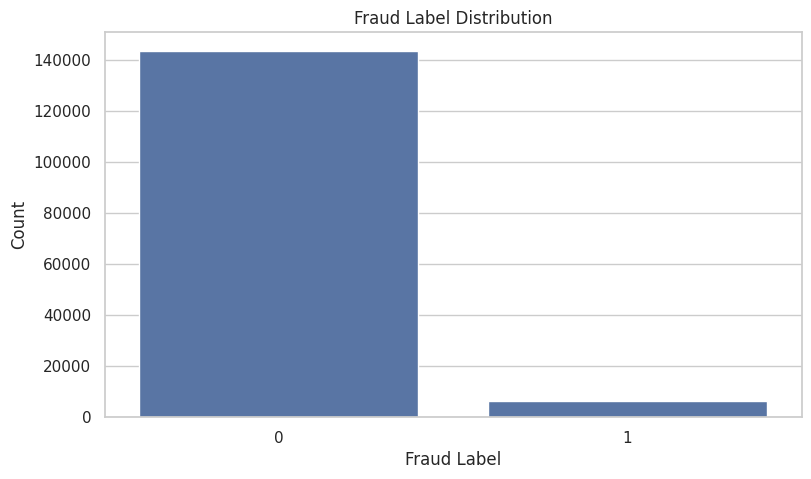

In [10]:
# 5. Conduct fraud-focused exploratory analysis before modeling

analysis_random_state = globals().get("RANDOM_STATE", 42)

overall_fraud_rate = df["fraud_label"].mean()

print(f"Overall fraud rate: {overall_fraud_rate:.4%}")

fraud_distribution = (
    df["fraud_label"]
      .value_counts()
      .sort_index()
      .rename_axis("fraud_label")
      .reset_index(name="count")
)

fraud_distribution["percentage"] = fraud_distribution["count"] / len(df)

display(fraud_distribution)

sns.countplot(data=df, x="fraud_label")
plt.title("Fraud Label Distribution")
plt.xlabel("Fraud Label")
plt.ylabel("Count")
plt.show()


Fraud rate by payment_method


,payment_method,N,fraud_count,fraud_rate,fraud_rate_lift
1,Crypto,30011,2209,0.0736,1.7440
4,UPI,30008,1066,0.0355,0.8417
2,Debit Card,29923,1030,0.0344,0.8156
3,PayPal,30195,1033,0.0342,0.8106
0,Credit Card,29863,993,0.0333,0.7878


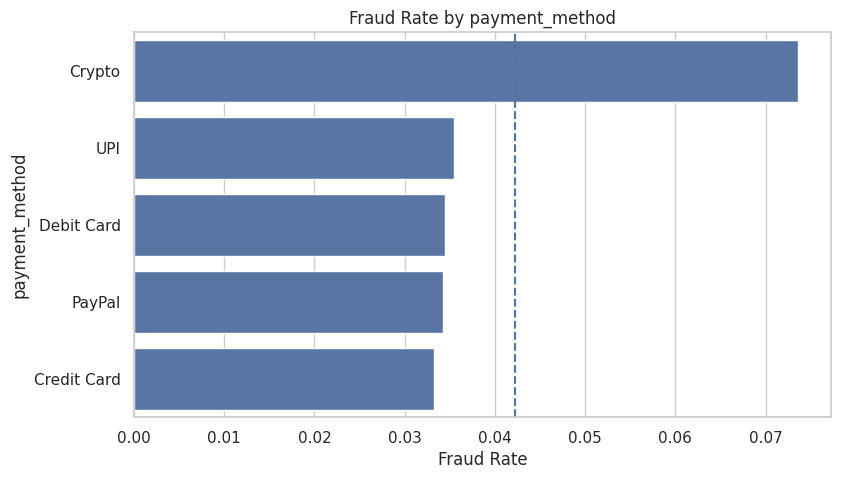


Fraud rate by device_type


,device_type,N,fraud_count,fraud_rate,fraud_rate_lift
2,Tablet,50088,2156,0.0430,1.0198
0,Desktop,49807,2124,0.0426,1.0104
1,Mobile,50105,2051,0.0409,0.9698


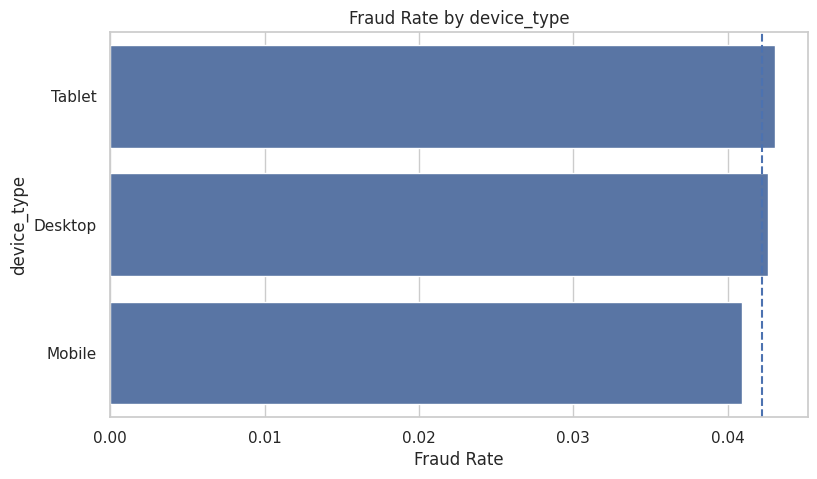


Fraud rate by category


,category,N,fraud_count,fraud_rate,fraud_rate_lift
0,Automotive,19969,892,0.0447,1.0583
7,Toys,18986,837,0.0441,1.0445
4,Fashion,19561,842,0.0430,1.0199
6,Sports,18210,776,0.0426,1.0096
2,Books,18790,788,0.0419,0.9936
3,Electronics,16587,692,0.0417,0.9885
1,Beauty,19917,803,0.0403,0.9552
5,Home & Kitchen,17980,701,0.0390,0.9237


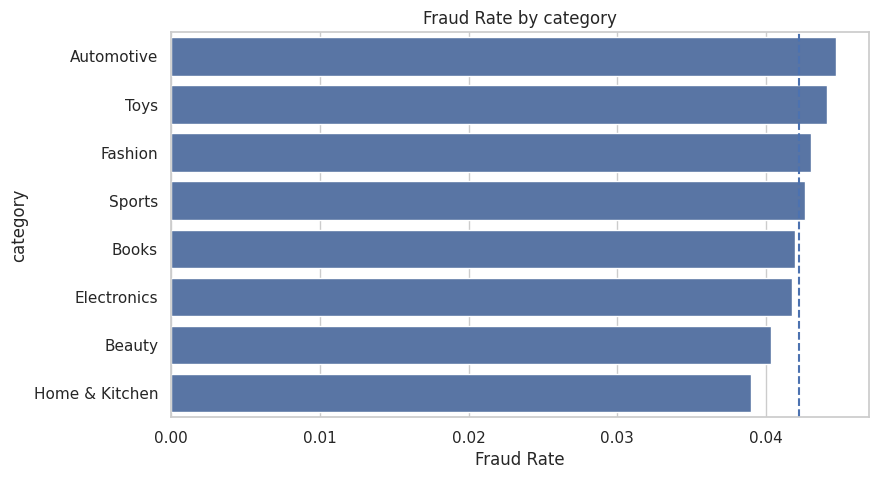


Fraud rate by gender


,gender,N,fraud_count,fraud_rate,fraud_rate_lift
1,Male,50793,2165,0.0426,1.0099
2,Other,49873,2112,0.0423,1.0033
0,Female,49334,2054,0.0416,0.9864


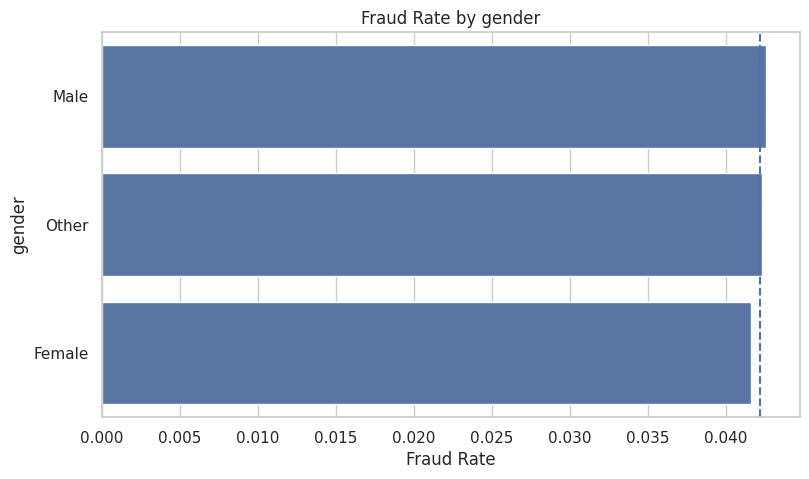


Fraud rate by country


,country,N,fraud_count,fraud_rate,fraud_rate_lift
5,India,18833,820,0.0435,1.0316
3,France,19411,837,0.0431,1.0216
7,USA,18998,812,0.0427,1.0127
4,Germany,18266,773,0.0423,1.0027
1,Brazil,19295,813,0.0421,0.9983
6,UK,18443,770,0.0418,0.9892
0,Australia,18140,746,0.0411,0.9744
2,Canada,18614,760,0.0408,0.9674


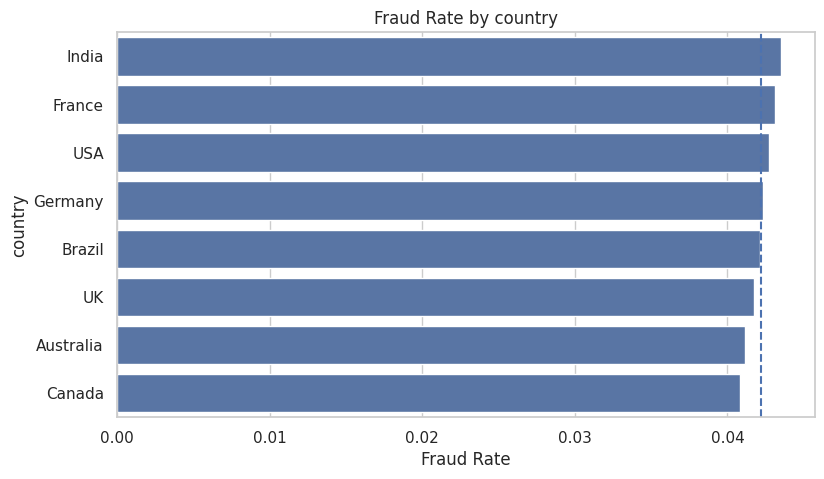

In [11]:
# 5.1 Compare fraud rates across categorical variables

cat_vars = ["payment_method", "device_type", "category", "gender", "country"]
cat_vars = [c for c in cat_vars if c in df.columns]

categorical_fraud_summaries = {}

for col in cat_vars:
    tmp = (
        df.groupby(col, observed=True)
          .agg(
              N=("fraud_label", "size"),
              fraud_count=("fraud_label", "sum"),
              fraud_rate=("fraud_label", "mean")
          )
          .reset_index()
    )

    tmp["fraud_rate_lift"] = tmp["fraud_rate"] / overall_fraud_rate
    tmp = tmp.sort_values("fraud_rate", ascending=False)

    categorical_fraud_summaries[col] = tmp

    print(f"\nFraud rate by {col}")
    display(tmp)

    sns.barplot(data=tmp, x="fraud_rate", y=col)
    plt.axvline(overall_fraud_rate, linestyle="--")
    plt.title(f"Fraud Rate by {col}")
    plt.xlabel("Fraud Rate")
    plt.ylabel(col)
    plt.show()

In [12]:
# 5.2 Compare numerical feature distributions by fraud label

num_eda = [
    "order_value", "discount_applied", "shipping_delay_days",
    "age", "loyalty_score", "lifetime_value",
    "price", "margin_percentage", "popularity_score",
    "avg_session_time", "pages_per_session", "cart_abandon_rate",
    "return_rate", "support_tickets", "review_score"
]

num_eda = [col for col in num_eda if col in df.columns]

numeric_summary_rows = []

for col in num_eda:
    legit = df.loc[df["fraud_label"] == 0, col].dropna()
    fraud = df.loc[df["fraud_label"] == 1, col].dropna()

    legit_mean = legit.mean()
    fraud_mean = fraud.mean()
    legit_median = legit.median()
    fraud_median = fraud.median()

    pooled_std = np.sqrt((legit.var() + fraud.var()) / 2)
    standardized_diff = (fraud_mean - legit_mean) / pooled_std if pooled_std > 0 else np.nan

    numeric_summary_rows.append({
        "variable": col,
        "legit_mean": legit_mean,
        "fraud_mean": fraud_mean,
        "mean_difference": fraud_mean - legit_mean,
        "legit_median": legit_median,
        "fraud_median": fraud_median,
        "median_difference": fraud_median - legit_median,
        "standardized_mean_difference": standardized_diff
    })

numeric_fraud_summary = (
    pd.DataFrame(numeric_summary_rows)
      .sort_values("standardized_mean_difference", key=lambda s: s.abs(), ascending=False)
)

display(numeric_fraud_summary)

,variable,legit_mean,fraud_mean,mean_difference,legit_median,fraud_median,median_difference,standardized_mean_difference
1,discount_applied,0.2484,0.2902,0.0419,0.2500,0.3300,0.0800,0.2859
2,shipping_delay_days,4.9851,5.4920,0.5070,5.0000,6.0000,1.0000,0.1584
0,order_value,384.2108,363.3239,-20.8870,373.0800,349.4500,-23.6300,-0.0929
8,popularity_score,49.0445,49.8445,0.8001,48.6000,49.8900,1.2900,0.0275
9,avg_session_time,10.4592,10.3372,-0.1220,10.4900,10.2400,-0.2500,-0.0223
5,lifetime_value,10027.6175,9926.7887,-100.8288,10009.7300,9777.0800,-232.6500,-0.0175
11,cart_abandon_rate,0.4968,0.5008,0.0041,0.5000,0.5000,0.0000,0.0143
12,return_rate,0.2503,0.2522,0.0019,0.2500,0.2500,0.0000,0.0131
7,margin_percentage,22.2669,22.3682,0.1013,22.1300,22.3400,0.2100,0.0099
4,loyalty_score,49.9821,49.7288,-0.2534,50.0000,49.8900,-0.1100,-0.0088


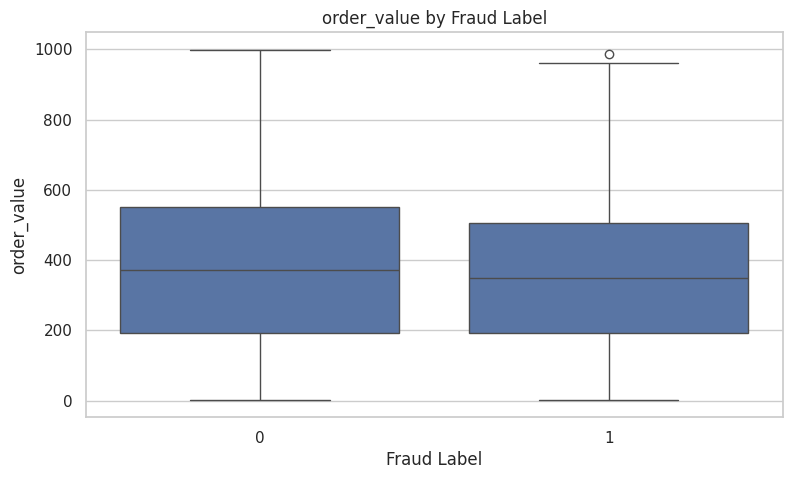

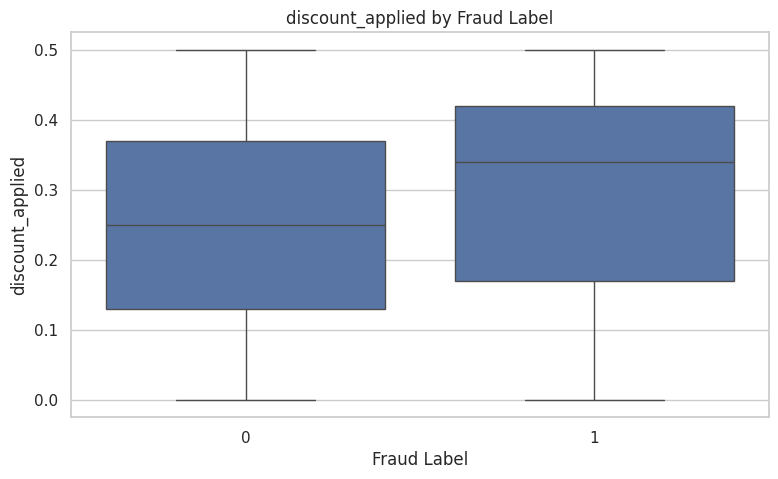

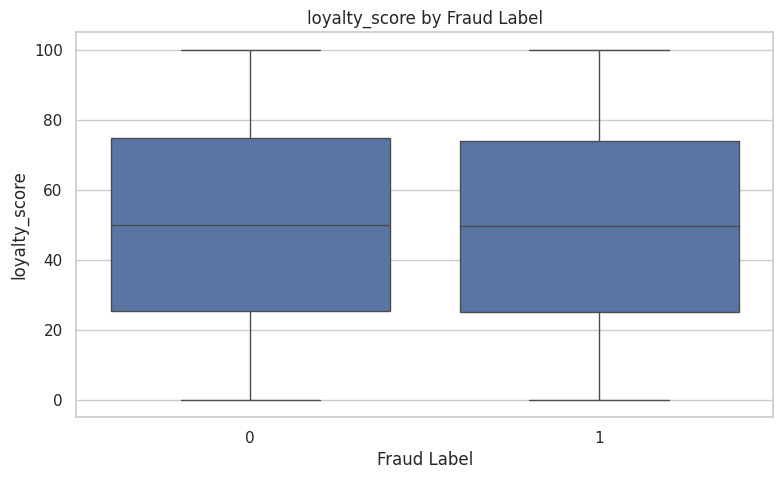

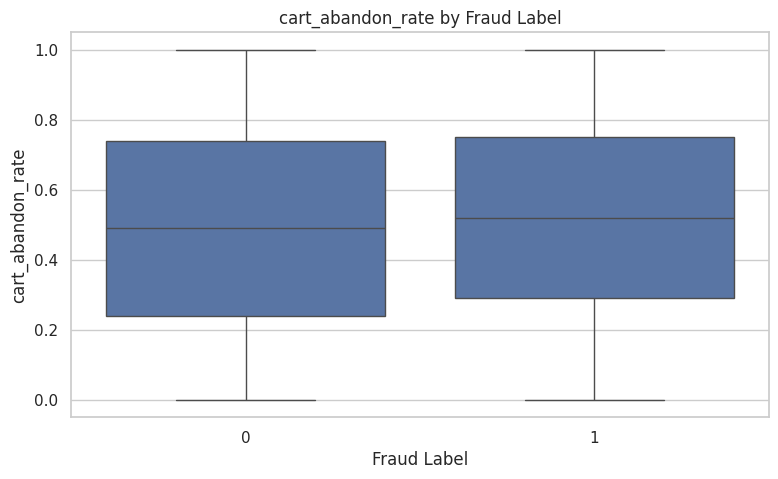

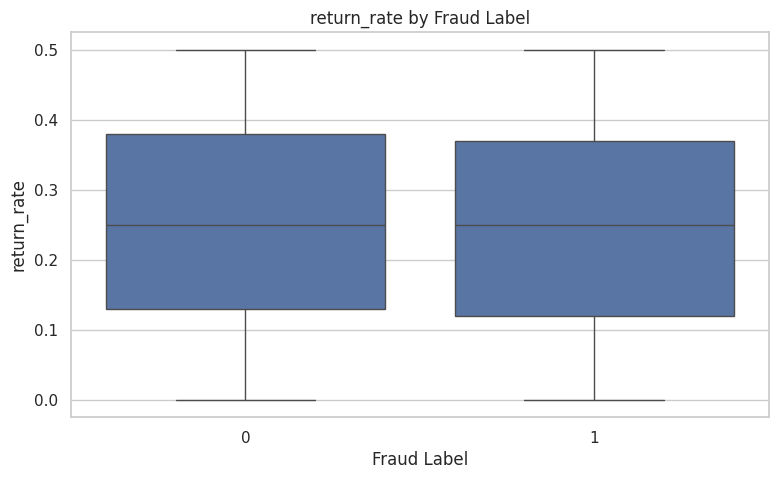

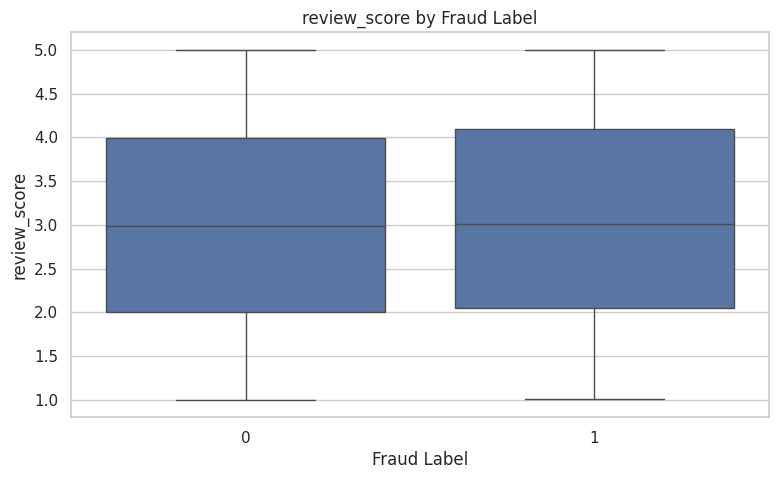

In [13]:
# 5.3 Visualize selected numerical variables using a sampled dataset

plot_sample = df.sample(
    n=min(len(df), 30000),
    random_state=analysis_random_state
)

selected_boxplot_vars = [
    "order_value",
    "discount_applied",
    "loyalty_score",
    "cart_abandon_rate",
    "return_rate",
    "review_score"
]

selected_boxplot_vars = [col for col in selected_boxplot_vars if col in plot_sample.columns]

for col in selected_boxplot_vars:
    sns.boxplot(data=plot_sample, x="fraud_label", y=col)
    plt.title(f"{col} by Fraud Label")
    plt.xlabel("Fraud Label")
    plt.ylabel(col)
    plt.show()

In [18]:
# 6. Engineer transaction, product, time, and prior-history features
pd.set_option("display.max_colwidth", 150)

model_df = df.copy()

model_df = model_df.sort_values(["order_date", "transaction_id"]).reset_index(drop=True)

model_df["discounted_order_value"] = model_df["order_value"] * (1 - model_df["discount_applied"])
model_df["discount_amount"] = model_df["order_value"] * model_df["discount_applied"]
model_df["log_order_value"] = np.log1p(model_df["order_value"])

model_df["margin_rate"] = model_df["margin_percentage"] / 100
model_df["estimated_margin_value"] = model_df["discounted_order_value"] * model_df["margin_rate"]

model_df["order_year"] = model_df["order_date"].dt.year
model_df["order_month"] = model_df["order_date"].dt.month
model_df["order_quarter"] = model_df["order_date"].dt.quarter
model_df["order_dayofweek"] = model_df["order_date"].dt.dayofweek
model_df["is_weekend_order"] = (model_df["order_dayofweek"] >= 5).astype(int)

model_df["order_month_sin"] = np.sin(2 * np.pi * model_df["order_month"] / 12)
model_df["order_month_cos"] = np.cos(2 * np.pi * model_df["order_month"] / 12)
model_df["order_dayofweek_sin"] = np.sin(2 * np.pi * model_df["order_dayofweek"] / 7)
model_df["order_dayofweek_cos"] = np.cos(2 * np.pi * model_df["order_dayofweek"] / 7)

model_df["raw_customer_tenure_days"] = (
    model_df["order_date"] - model_df["registration_date"]
).dt.days

model_df["registration_after_order_flag"] = (
    model_df["raw_customer_tenure_days"] < 0
).astype(int)

model_df["customer_tenure_days"] = model_df["raw_customer_tenure_days"].clip(lower=0)
model_df["is_new_customer"] = (model_df["customer_tenure_days"] <= 30).astype(int)

tenure_inconsistency_count = int(model_df["registration_after_order_flag"].sum())
tenure_inconsistency_rate = tenure_inconsistency_count / len(model_df)

print("Transactions with registration date after order date:", tenure_inconsistency_count)
print(f"Registration-order inconsistency rate: {tenure_inconsistency_rate:.2%}")

registration_inconsistency_summary = (
    model_df.groupby("registration_after_order_flag")
            .agg(
                N=("fraud_label", "size"),
                fraud_count=("fraud_label", "sum"),
                fraud_rate=("fraud_label", "mean")
            )
            .reset_index()
)

registration_inconsistency_summary["fraud_rate_lift"] = (
    registration_inconsistency_summary["fraud_rate"] / model_df["fraud_label"].mean()
)

display(registration_inconsistency_summary)

model_df["prior_customer_transaction_count"] = (
    model_df.groupby("customer_id", sort=False).cumcount()
)

model_df["prior_customer_order_value_sum"] = (
    model_df.groupby("customer_id", sort=False)["order_value"].cumsum()
    - model_df["order_value"]
)

model_df["prior_customer_avg_order_value"] = (
    model_df["prior_customer_order_value_sum"]
    / model_df["prior_customer_transaction_count"].replace(0, np.nan)
)

model_df["previous_order_date"] = (
    model_df.groupby("customer_id", sort=False)["order_date"].shift(1)
)

model_df["days_since_last_order"] = (
    model_df["order_date"] - model_df["previous_order_date"]
).dt.days

model_df["is_first_customer_transaction"] = (
    model_df["prior_customer_transaction_count"] == 0
).astype(int)

model_df["prior_product_transaction_count"] = (
    model_df.groupby("product_id", sort=False).cumcount()
)

model_df["prior_product_order_value_sum"] = (
    model_df.groupby("product_id", sort=False)["order_value"].cumsum()
    - model_df["order_value"]
)

model_df["prior_product_avg_order_value"] = (
    model_df["prior_product_order_value_sum"]
    / model_df["prior_product_transaction_count"].replace(0, np.nan)
)

model_df["is_first_product_transaction"] = (
    model_df["prior_product_transaction_count"] == 0
).astype(int)

model_df["prior_customer_avg_order_value"] = model_df["prior_customer_avg_order_value"].fillna(0)
model_df["days_since_last_order"] = model_df["days_since_last_order"].fillna(0)
model_df["prior_product_avg_order_value"] = model_df["prior_product_avg_order_value"].fillna(0)

model_df = model_df.drop(
    columns=[
        "prior_customer_order_value_sum",
        "previous_order_date",
        "prior_product_order_value_sum"
    ],
    errors="ignore"
)

diagnostic_engineered_features = [
    "raw_customer_tenure_days",
    "registration_after_order_flag",
    "customer_tenure_days",
    "is_new_customer"
]

primary_engineered_features = [
    "discounted_order_value",
    "discount_amount",
    "log_order_value",
    "margin_rate",
    "estimated_margin_value",
    "order_year",
    "order_month",
    "order_quarter",
    "order_dayofweek",
    "is_weekend_order",
    "order_month_sin",
    "order_month_cos",
    "order_dayofweek_sin",
    "order_dayofweek_cos",
    "prior_customer_transaction_count",
    "prior_customer_avg_order_value",
    "days_since_last_order",
    "is_first_customer_transaction",
    "prior_product_transaction_count",
    "prior_product_avg_order_value",
    "is_first_product_transaction"
]

all_engineered_features = primary_engineered_features + diagnostic_engineered_features

feature_decision_summary = pd.DataFrame({
    "feature": all_engineered_features,
    "included_in_primary_model": [
        feature in primary_engineered_features for feature in all_engineered_features
    ],
    "feature_role": [
        "primary predictive feature" if feature in primary_engineered_features
        else "diagnostic only"
        for feature in all_engineered_features
    ],
    "reason": [
        "Included because it is observable at transaction time or constructed only from prior transaction history"
        if feature in primary_engineered_features
        else "Excluded from primary modeling because registration dates occur after order dates for a large share of transactions"
        for feature in all_engineered_features
    ]
})

display(feature_decision_summary)

feature_audit = pd.DataFrame({
    "feature": all_engineered_features,
    "dtype": model_df[all_engineered_features].dtypes.astype(str).values,
    "missing_count": model_df[all_engineered_features].isna().sum().values,
    "missing_rate": model_df[all_engineered_features].isna().mean().values,
    "infinite_count": np.isinf(
        model_df[all_engineered_features].select_dtypes(include=[np.number])
    ).sum().reindex(all_engineered_features, fill_value=0).values
})

display(feature_audit)

print("Number of primary engineered features:", len(primary_engineered_features))
print("Number of diagnostic engineered features:", len(diagnostic_engineered_features))

print("\nPrimary engineered features preview:")
display(model_df[primary_engineered_features].head())

df = model_df.copy()

Transactions with registration date after order date: 49801
Registration-order inconsistency rate: 33.20%


,registration_after_order_flag,N,fraud_count,fraud_rate,fraud_rate_lift
0,0,100199,4242,0.0423,1.0031
1,1,49801,2089,0.0419,0.9938


,feature,included_in_primary_model,feature_role,reason
0,discounted_order_value,True,primary predictive feature,Included because it is observable at transaction time or constructed only from prior transaction history
1,discount_amount,True,primary predictive feature,Included because it is observable at transaction time or constructed only from prior transaction history
2,log_order_value,True,primary predictive feature,Included because it is observable at transaction time or constructed only from prior transaction history
3,margin_rate,True,primary predictive feature,Included because it is observable at transaction time or constructed only from prior transaction history
4,estimated_margin_value,True,primary predictive feature,Included because it is observable at transaction time or constructed only from prior transaction history
5,order_year,True,primary predictive feature,Included because it is observable at transaction time or constructed only from prior transaction history
6,order_month,True,primary predictive feature,Included because it is observable at transaction time or constructed only from prior transaction history
7,order_quarter,True,primary predictive feature,Included because it is observable at transaction time or constructed only from prior transaction history
8,order_dayofweek,True,primary predictive feature,Included because it is observable at transaction time or constructed only from prior transaction history
9,is_weekend_order,True,primary predictive feature,Included because it is observable at transaction time or constructed only from prior transaction history


,feature,dtype,missing_count,missing_rate,infinite_count
0,discounted_order_value,float64,0,0.0000,0
1,discount_amount,float64,0,0.0000,0
2,log_order_value,float64,0,0.0000,0
3,margin_rate,float64,0,0.0000,0
4,estimated_margin_value,float64,0,0.0000,0
5,order_year,int32,0,0.0000,0
6,order_month,int32,0,0.0000,0
7,order_quarter,int32,0,0.0000,0
8,order_dayofweek,int32,0,0.0000,0
9,is_weekend_order,int64,0,0.0000,0


Number of primary engineered features: 21
Number of diagnostic engineered features: 4

Primary engineered features preview:


,discounted_order_value,discount_amount,log_order_value,margin_rate,estimated_margin_value,order_year,order_month,order_quarter,order_dayofweek,is_weekend_order,order_month_sin,order_month_cos,order_dayofweek_sin,order_dayofweek_cos,prior_customer_transaction_count,prior_customer_avg_order_value,days_since_last_order,is_first_customer_transaction,prior_product_transaction_count,prior_product_avg_order_value,is_first_product_transaction
0,621.9864,136.5336,6.6327,0.0697,43.3525,2019,1,1,1,0,0.5000,0.8660,0.7818,0.6235,0,0.0000,0.0000,1,0,0.0000,1
1,440.3704,179.8696,6.4317,0.3063,134.8855,2019,1,1,1,0,0.5000,0.8660,0.7818,0.6235,0,0.0000,0.0000,1,0,0.0000,1
2,518.4179,51.2721,6.3468,0.1933,100.2102,2019,1,1,1,0,0.5000,0.8660,0.7818,0.6235,0,0.0000,0.0000,1,0,0.0000,1
3,541.1560,11.0440,6.3157,0.3198,173.0617,2019,1,1,1,0,0.5000,0.8660,0.7818,0.6235,0,0.0000,0.0000,1,0,0.0000,1
4,171.7584,23.4216,5.2790,0.2816,48.3672,2019,1,1,1,0,0.5000,0.8660,0.7818,0.6235,0,0.0000,0.0000,1,0,0.0000,1


In [19]:
# 7. Define leakage controls and modeling feature groups

TARGET = "fraud_label"

leakage_risk_features = [
    "shipping_delay_days",
    "lifetime_value",
    "churn_label",
    "behavior_churn_signal"
]

identifier_and_date_features = [
    "transaction_id",
    "customer_id",
    "product_id",
    "order_date",
    "registration_date"
]

diagnostic_only_features = [
    "raw_customer_tenure_days",
    "registration_after_order_flag",
    "customer_tenure_days",
    "is_new_customer"
]

excluded_features = (
    leakage_risk_features
    + identifier_and_date_features
    + diagnostic_only_features
    + [TARGET]
)

transaction_raw_features = [
    "order_value",
    "discount_applied",
    "payment_method",
    "device_type"
]

transaction_engineered_features = [
    "discounted_order_value",
    "discount_amount",
    "log_order_value",
    "order_year",
    "order_month",
    "order_quarter",
    "order_dayofweek",
    "is_weekend_order",
    "order_month_sin",
    "order_month_cos",
    "order_dayofweek_sin",
    "order_dayofweek_cos"
]

customer_features = [
    "age",
    "gender",
    "country",
    "loyalty_score"
]

product_features = [
    "category",
    "price",
    "margin_percentage",
    "popularity_score",
    "margin_rate",
    "estimated_margin_value"
]

behavior_features = [
    "avg_session_time",
    "pages_per_session",
    "cart_abandon_rate",
    "return_rate",
    "support_tickets",
    "review_score"
]

prior_history_features = [
    "prior_customer_transaction_count",
    "prior_customer_avg_order_value",
    "days_since_last_order",
    "is_first_customer_transaction",
    "prior_product_transaction_count",
    "prior_product_avg_order_value",
    "is_first_product_transaction"
]

transaction_only_features = (
    transaction_raw_features
    + transaction_engineered_features
)

integrated_features = (
    transaction_only_features
    + customer_features
    + product_features
    + behavior_features
    + prior_history_features
)

transaction_only_features = [
    feature for feature in transaction_only_features
    if feature in df.columns and feature not in excluded_features
]

integrated_features = [
    feature for feature in integrated_features
    if feature in df.columns and feature not in excluded_features
]

missing_transaction_features = [
    feature for feature in transaction_raw_features + transaction_engineered_features
    if feature not in df.columns
]

missing_integrated_features = [
    feature for feature in (
        transaction_raw_features
        + transaction_engineered_features
        + customer_features
        + product_features
        + behavior_features
        + prior_history_features
    )
    if feature not in df.columns
]

if missing_transaction_features:
    print("Missing transaction-only candidate features:", missing_transaction_features)

if missing_integrated_features:
    print("Missing integrated candidate features:", missing_integrated_features)

feature_group_summary = pd.DataFrame([
    {
        "feature_group": "transaction_only_features",
        "n_features": len(transaction_only_features),
        "features": transaction_only_features
    },
    {
        "feature_group": "integrated_features",
        "n_features": len(integrated_features),
        "features": integrated_features
    },
    {
        "feature_group": "excluded_leakage_risk_features",
        "n_features": len([f for f in leakage_risk_features if f in df.columns]),
        "features": [f for f in leakage_risk_features if f in df.columns]
    },
    {
        "feature_group": "excluded_identifier_date_features",
        "n_features": len([f for f in identifier_and_date_features if f in df.columns]),
        "features": [f for f in identifier_and_date_features if f in df.columns]
    },
    {
        "feature_group": "diagnostic_only_features",
        "n_features": len([f for f in diagnostic_only_features if f in df.columns]),
        "features": [f for f in diagnostic_only_features if f in df.columns]
    }
])

display(feature_group_summary)

y = df[TARGET].astype(int)

print("Target distribution:")
display(
    y.value_counts()
     .sort_index()
     .rename_axis("fraud_label")
     .reset_index(name="count")
     .assign(percentage=lambda x: x["count"] / len(y))
)

print("Number of transaction-only features:", len(transaction_only_features))
print("Number of integrated features:", len(integrated_features))

,feature_group,n_features,features
0,transaction_only_features,16,"[order_value, discount_applied, payment_method, device_type, discounted_order_value, discount_amount, log_order_value, order_year, order_month, or..."
1,integrated_features,39,"[order_value, discount_applied, payment_method, device_type, discounted_order_value, discount_amount, log_order_value, order_year, order_month, or..."
2,excluded_leakage_risk_features,4,"[shipping_delay_days, lifetime_value, churn_label, behavior_churn_signal]"
3,excluded_identifier_date_features,5,"[transaction_id, customer_id, product_id, order_date, registration_date]"
4,diagnostic_only_features,4,"[raw_customer_tenure_days, registration_after_order_flag, customer_tenure_days, is_new_customer]"


Target distribution:


,fraud_label,count,percentage
0,0,143669,0.9578
1,1,6331,0.0422


Number of transaction-only features: 16
Number of integrated features: 39


In [20]:
# 7.1 Split modeling features into numeric and categorical groups

def split_numeric_categorical_features(data, feature_list):
    numeric_features = [
        feature for feature in feature_list
        if pd.api.types.is_numeric_dtype(data[feature])
    ]

    categorical_features = [
        feature for feature in feature_list
        if not pd.api.types.is_numeric_dtype(data[feature])
    ]

    return numeric_features, categorical_features

txn_numeric_features, txn_categorical_features = split_numeric_categorical_features(
    df,
    transaction_only_features
)

int_numeric_features, int_categorical_features = split_numeric_categorical_features(
    df,
    integrated_features
)

feature_type_summary = pd.DataFrame([
    {
        "feature_set": "transaction_only",
        "n_numeric": len(txn_numeric_features),
        "n_categorical": len(txn_categorical_features),
        "numeric_features": txn_numeric_features,
        "categorical_features": txn_categorical_features
    },
    {
        "feature_set": "integrated",
        "n_numeric": len(int_numeric_features),
        "n_categorical": len(int_categorical_features),
        "numeric_features": int_numeric_features,
        "categorical_features": int_categorical_features
    }
])

display(feature_type_summary)

,feature_set,n_numeric,n_categorical,numeric_features,categorical_features
0,transaction_only,14,2,"[order_value, discount_applied, discounted_order_value, discount_amount, log_order_value, order_year, order_month, order_quarter, order_dayofweek,...","[payment_method, device_type]"
1,integrated,34,5,"[order_value, discount_applied, discounted_order_value, discount_amount, log_order_value, order_year, order_month, order_quarter, order_dayofweek,...","[payment_method, device_type, gender, country, category]"


In [21]:
# 7.2 Validate final feature groups

feature_validation_summary = pd.DataFrame([
    {
        "check": "excluded features in transaction_only_features",
        "n_violations": len(set(transaction_only_features) & set(excluded_features)),
        "violating_features": list(set(transaction_only_features) & set(excluded_features))
    },
    {
        "check": "excluded features in integrated_features",
        "n_violations": len(set(integrated_features) & set(excluded_features)),
        "violating_features": list(set(integrated_features) & set(excluded_features))
    },
    {
        "check": "missing values in transaction_only_features",
        "n_violations": int(df[transaction_only_features].isna().sum().sum()),
        "violating_features": df[transaction_only_features].columns[
            df[transaction_only_features].isna().any()
        ].tolist()
    },
    {
        "check": "missing values in integrated_features",
        "n_violations": int(df[integrated_features].isna().sum().sum()),
        "violating_features": df[integrated_features].columns[
            df[integrated_features].isna().any()
        ].tolist()
    }
])

display(feature_validation_summary)

,check,n_violations,violating_features
0,excluded features in transaction_only_features,0,[]
1,excluded features in integrated_features,0,[]
2,missing values in transaction_only_features,0,[]
3,missing values in integrated_features,0,[]


In [22]:
# 8. Create chronological train, validation, and test splits

df = df.sort_values(["order_date", "transaction_id"]).reset_index(drop=True)

y = df[TARGET].astype(int)

n = len(df)
train_end = int(n * 0.60)
val_end = int(n * 0.80)

idx_train = np.arange(0, train_end)
idx_val = np.arange(train_end, val_end)
idx_test = np.arange(val_end, n)

split_summary = pd.DataFrame([
    {
        "split": "train",
        "n_rows": len(idx_train),
        "sample_share": len(idx_train) / n,
        "fraud_rate": y.iloc[idx_train].mean(),
        "start_date": df["order_date"].iloc[idx_train].min(),
        "end_date": df["order_date"].iloc[idx_train].max()
    },
    {
        "split": "validation",
        "n_rows": len(idx_val),
        "sample_share": len(idx_val) / n,
        "fraud_rate": y.iloc[idx_val].mean(),
        "start_date": df["order_date"].iloc[idx_val].min(),
        "end_date": df["order_date"].iloc[idx_val].max()
    },
    {
        "split": "test",
        "n_rows": len(idx_test),
        "sample_share": len(idx_test) / n,
        "fraud_rate": y.iloc[idx_test].mean(),
        "start_date": df["order_date"].iloc[idx_test].min(),
        "end_date": df["order_date"].iloc[idx_test].max()
    }
])

display(split_summary)

chronology_checks = pd.DataFrame([
    {
        "check": "train ends before or at validation starts",
        "passed": df["order_date"].iloc[idx_train].max() <= df["order_date"].iloc[idx_val].min()
    },
    {
        "check": "validation ends before or at test starts",
        "passed": df["order_date"].iloc[idx_val].max() <= df["order_date"].iloc[idx_test].min()
    },
    {
        "check": "all rows assigned to exactly one split",
        "passed": len(idx_train) + len(idx_val) + len(idx_test) == n
    }
])

display(chronology_checks)

,split,n_rows,sample_share,fraud_rate,start_date,end_date
0,train,90000,0.6000,0.0422,2019-01-01,2022-04-16
1,validation,30000,0.2000,0.0429,2022-04-16,2023-05-19
2,test,30000,0.2000,0.0416,2023-05-19,2024-06-23


,check,passed
0,train ends before or at validation starts,True
1,validation ends before or at test starts,True
2,all rows assigned to exactly one split,True


In [23]:
# 9. Define preprocessing, evaluation, threshold tuning, and candidate model utilities

analysis_random_state = globals().get("RANDOM_STATE", 42)

def make_ohe():
    """Create a version-compatible one-hot encoder."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor(numeric_features, categorical_features):
    """Build a preprocessing pipeline for numeric and categorical features."""
    numeric_transformer = SklearnPipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = SklearnPipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )

    return preprocessor

def get_positive_class_probability(model, X):
    """Return positive-class predicted probabilities or normalized decision scores."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        score_range = scores.max() - scores.min()
        return (scores - scores.min()) / (score_range + 1e-9)

    raise AttributeError("Model must support either predict_proba or decision_function.")

def evaluate_binary_classifier(y_true, predicted_probability, threshold=0.5):
    """Evaluate binary fraud classification performance at a given threshold."""
    y_true = np.asarray(y_true).astype(int)
    predicted_probability = np.asarray(predicted_probability)
    predicted_label = (predicted_probability >= threshold).astype(int)

    metrics = {
        "PR_AUC": average_precision_score(y_true, predicted_probability),
        "Precision": precision_score(y_true, predicted_label, zero_division=0),
        "Recall": recall_score(y_true, predicted_label, zero_division=0),
        "F1": f1_score(y_true, predicted_label, zero_division=0),
        "Threshold": threshold
    }

    if len(np.unique(y_true)) == 2:
        metrics["ROC_AUC"] = roc_auc_score(y_true, predicted_probability)
    else:
        metrics["ROC_AUC"] = np.nan

    return metrics

def tune_threshold_by_f1(y_true, predicted_probability):
    """Select the probability threshold that maximizes validation-set F1."""
    precision, recall, thresholds = precision_recall_curve(y_true, predicted_probability)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

    if len(thresholds) == 0:
        return 0.5, np.nan, np.nan, np.nan

    best_index = np.nanargmax(f1_scores[:-1])
    best_threshold = thresholds[best_index]

    return {
        "best_threshold": float(best_threshold),
        "validation_f1": float(f1_scores[best_index]),
        "validation_precision": float(precision[best_index]),
        "validation_recall": float(recall[best_index])
    }

def make_candidate_models(y_train):
    """Define candidate fraud detection models with imbalance-aware settings where supported."""
    y_train = pd.Series(y_train).astype(int)
    n_positive = y_train.sum()
    n_negative = len(y_train) - n_positive
    scale_pos_weight = n_negative / max(n_positive, 1)

    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=analysis_random_state
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=250,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=analysis_random_state
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=1e-4,
            max_iter=100,
            early_stopping=True,
            random_state=analysis_random_state
        )
    }

    try:
        models["XGBoost"] = XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=analysis_random_state,
            n_jobs=-1
        )
    except Exception as error:
        print("XGBoost skipped:", error)

    try:
        models["LightGBM"] = LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            class_weight="balanced",
            random_state=analysis_random_state,
            n_jobs=-1,
            verbose=-1
        )
    except Exception as error:
        print("LightGBM skipped:", error)

    return models

In [24]:
# 10. Train and evaluate transaction-only and integrated feature sets

def run_feature_set(feature_set_name, feature_list, numeric_features, categorical_features):
    """Train and evaluate candidate models for one modeling feature set."""
    print("\n" + "#" * 90)
    print("Feature set:", feature_set_name)
    print("#" * 90)

    X = df[feature_list].copy()

    X_train = X.iloc[idx_train]
    X_val = X.iloc[idx_val]
    X_test = X.iloc[idx_test]

    y_train = y.iloc[idx_train]
    y_val = y.iloc[idx_val]
    y_test = y.iloc[idx_test]

    preprocessor = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)
    X_test_processed = preprocessor.transform(X_test)

    try:
        processed_feature_names = preprocessor.get_feature_names_out()
    except Exception:
        processed_feature_names = np.array([
            f"feature_{i}" for i in range(X_train_processed.shape[1])
        ])

    print("Raw features:", len(feature_list))
    print("Processed features:", X_train_processed.shape[1])
    print("Numeric features:", len(numeric_features))
    print("Categorical features:", len(categorical_features))

    models = make_candidate_models(y_train)

    fitted_models = {}
    result_rows = []
    threshold_rows = []

    for model_name, model in models.items():
        print("\nTraining:", model_name)

        if model_name == "MLP":
            oversampler = RandomOverSampler(
                sampling_strategy=0.30,
                random_state=analysis_random_state
            )
            X_train_resampled, y_train_resampled = oversampler.fit_resample(
                X_train_processed,
                y_train
            )
            model.fit(X_train_resampled, y_train_resampled)
        else:
            model.fit(X_train_processed, y_train)

        fitted_models[model_name] = model

        val_probability = get_positive_class_probability(model, X_val_processed)
        test_probability = get_positive_class_probability(model, X_test_processed)

        val_default_metrics = evaluate_binary_classifier(
            y_val,
            val_probability,
            threshold=0.5
        )

        test_default_metrics = evaluate_binary_classifier(
            y_test,
            test_probability,
            threshold=0.5
        )

        threshold_info = tune_threshold_by_f1(
            y_val,
            val_probability
        )

        tuned_threshold = threshold_info["best_threshold"]

        test_tuned_metrics = evaluate_binary_classifier(
            y_test,
            test_probability,
            threshold=tuned_threshold
        )

        result_rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "threshold_type": "default_0.50",
            "threshold": 0.5,
            "validation_PR_AUC": val_default_metrics["PR_AUC"],
            "validation_ROC_AUC": val_default_metrics["ROC_AUC"],
            "validation_precision": val_default_metrics["Precision"],
            "validation_recall": val_default_metrics["Recall"],
            "validation_F1": val_default_metrics["F1"],
            "test_PR_AUC": test_default_metrics["PR_AUC"],
            "test_ROC_AUC": test_default_metrics["ROC_AUC"],
            "test_precision": test_default_metrics["Precision"],
            "test_recall": test_default_metrics["Recall"],
            "test_F1": test_default_metrics["F1"]
        })

        result_rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "threshold_type": "validation_tuned_F1",
            "threshold": tuned_threshold,
            "validation_PR_AUC": val_default_metrics["PR_AUC"],
            "validation_ROC_AUC": val_default_metrics["ROC_AUC"],
            "validation_precision": threshold_info["validation_precision"],
            "validation_recall": threshold_info["validation_recall"],
            "validation_F1": threshold_info["validation_f1"],
            "test_PR_AUC": test_tuned_metrics["PR_AUC"],
            "test_ROC_AUC": test_tuned_metrics["ROC_AUC"],
            "test_precision": test_tuned_metrics["Precision"],
            "test_recall": test_tuned_metrics["Recall"],
            "test_F1": test_tuned_metrics["F1"]
        })

        threshold_rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "validation_tuned_threshold": tuned_threshold,
            "validation_precision_at_tuned_threshold": threshold_info["validation_precision"],
            "validation_recall_at_tuned_threshold": threshold_info["validation_recall"],
            "validation_F1_at_tuned_threshold": threshold_info["validation_f1"]
        })

    results = pd.DataFrame(result_rows)
    threshold_summary = pd.DataFrame(threshold_rows)

    bundle = {
        "feature_set_name": feature_set_name,
        "raw_features": feature_list,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "preprocessor": preprocessor,
        "processed_feature_names": processed_feature_names,
        "fitted_models": fitted_models,
        "X_train_processed": X_train_processed,
        "X_val_processed": X_val_processed,
        "X_test_processed": X_test_processed,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "threshold_summary": threshold_summary
    }

    return results, bundle


results_transaction_only, bundle_transaction_only = run_feature_set(
    feature_set_name="transaction_only",
    feature_list=transaction_only_features,
    numeric_features=txn_numeric_features,
    categorical_features=txn_categorical_features
)

results_integrated, bundle_integrated = run_feature_set(
    feature_set_name="integrated",
    feature_list=integrated_features,
    numeric_features=int_numeric_features,
    categorical_features=int_categorical_features
)

results_all = pd.concat(
    [results_transaction_only, results_integrated],
    ignore_index=True
)

results_all = results_all.sort_values(
    by=["threshold_type", "test_PR_AUC", "test_F1"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(results_all)


##########################################################################################
Feature set: transaction_only
##########################################################################################
Raw features: 16
Processed features: 22
Numeric features: 14
Categorical features: 2

Training: Logistic Regression

Training: Random Forest

Training: MLP

Training: XGBoost

Training: LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



##########################################################################################
Feature set: integrated
##########################################################################################
Raw features: 39
Processed features: 61
Numeric features: 34
Categorical features: 5

Training: Logistic Regression

Training: Random Forest

Training: MLP

Training: XGBoost

Training: LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,feature_set,model,threshold_type,threshold,validation_PR_AUC,validation_ROC_AUC,validation_precision,validation_recall,validation_F1,test_PR_AUC,test_ROC_AUC,test_precision,test_recall,test_F1
0,transaction_only,Logistic Regression,validation_tuned_F1,0.5723,0.0709,0.6304,0.0789,0.3144,0.1261,0.0702,0.6340,0.0766,0.2946,0.1216
1,integrated,Logistic Regression,validation_tuned_F1,0.5752,0.0708,0.6266,0.0794,0.3385,0.1287,0.0695,0.6328,0.0756,0.2970,0.1205
2,transaction_only,XGBoost,validation_tuned_F1,0.4987,0.0640,0.6098,0.0693,0.4666,0.1207,0.0612,0.6092,0.0657,0.4452,0.1145
3,transaction_only,LightGBM,validation_tuned_F1,0.4746,0.0620,0.5953,0.0652,0.3975,0.1120,0.0607,0.5981,0.0653,0.4043,0.1124
4,integrated,Random Forest,validation_tuned_F1,0.1439,0.0689,0.6104,0.0719,0.3207,0.1174,0.0605,0.6040,0.0633,0.2850,0.1036
5,transaction_only,Random Forest,validation_tuned_F1,0.2084,0.0627,0.6037,0.0708,0.3067,0.1151,0.0603,0.6098,0.0653,0.2898,0.1066
6,transaction_only,MLP,validation_tuned_F1,0.2045,0.0550,0.5700,0.0577,0.3587,0.0995,0.0525,0.5622,0.0548,0.2050,0.0865
7,integrated,LightGBM,validation_tuned_F1,0.3887,0.0548,0.5705,0.0579,0.3866,0.1007,0.0517,0.5530,0.0480,0.5709,0.0886
8,integrated,XGBoost,validation_tuned_F1,0.4249,0.0569,0.5727,0.0611,0.3028,0.1017,0.0475,0.5246,0.0523,0.1209,0.0731
9,integrated,MLP,validation_tuned_F1,0.0054,0.0482,0.5327,0.0467,0.6786,0.0873,0.0462,0.5368,0.0456,0.5901,0.0846


In [25]:
# 10.1 Rank models using validation-tuned thresholds

tuned_results = (
    results_all[results_all["threshold_type"] == "validation_tuned_F1"]
    .sort_values(["test_PR_AUC", "test_F1"], ascending=False)
    .reset_index(drop=True)
)

display(tuned_results)

,feature_set,model,threshold_type,threshold,validation_PR_AUC,validation_ROC_AUC,validation_precision,validation_recall,validation_F1,test_PR_AUC,test_ROC_AUC,test_precision,test_recall,test_F1
0,transaction_only,Logistic Regression,validation_tuned_F1,0.5723,0.0709,0.6304,0.0789,0.3144,0.1261,0.0702,0.6340,0.0766,0.2946,0.1216
1,integrated,Logistic Regression,validation_tuned_F1,0.5752,0.0708,0.6266,0.0794,0.3385,0.1287,0.0695,0.6328,0.0756,0.2970,0.1205
2,transaction_only,XGBoost,validation_tuned_F1,0.4987,0.0640,0.6098,0.0693,0.4666,0.1207,0.0612,0.6092,0.0657,0.4452,0.1145
3,transaction_only,LightGBM,validation_tuned_F1,0.4746,0.0620,0.5953,0.0652,0.3975,0.1120,0.0607,0.5981,0.0653,0.4043,0.1124
4,integrated,Random Forest,validation_tuned_F1,0.1439,0.0689,0.6104,0.0719,0.3207,0.1174,0.0605,0.6040,0.0633,0.2850,0.1036
5,transaction_only,Random Forest,validation_tuned_F1,0.2084,0.0627,0.6037,0.0708,0.3067,0.1151,0.0603,0.6098,0.0653,0.2898,0.1066
6,transaction_only,MLP,validation_tuned_F1,0.2045,0.0550,0.5700,0.0577,0.3587,0.0995,0.0525,0.5622,0.0548,0.2050,0.0865
7,integrated,LightGBM,validation_tuned_F1,0.3887,0.0548,0.5705,0.0579,0.3866,0.1007,0.0517,0.5530,0.0480,0.5709,0.0886
8,integrated,XGBoost,validation_tuned_F1,0.4249,0.0569,0.5727,0.0611,0.3028,0.1017,0.0475,0.5246,0.0523,0.1209,0.0731
9,integrated,MLP,validation_tuned_F1,0.0054,0.0482,0.5327,0.0467,0.6786,0.0873,0.0462,0.5368,0.0456,0.5901,0.0846


In [26]:
# 10.2 Compare best transaction-only and integrated models

best_by_feature_set = (
    tuned_results
    .sort_values(["feature_set", "test_PR_AUC", "test_F1"], ascending=[True, False, False])
    .groupby("feature_set", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(best_by_feature_set)

if set(best_by_feature_set["feature_set"]) == {"transaction_only", "integrated"}:
    txn_best = best_by_feature_set.loc[
        best_by_feature_set["feature_set"] == "transaction_only"
    ].iloc[0]

    int_best = best_by_feature_set.loc[
        best_by_feature_set["feature_set"] == "integrated"
    ].iloc[0]

    comparison_summary = pd.DataFrame([
        {
            "metric": "test_PR_AUC_difference_integrated_minus_transaction_only",
            "value": int_best["test_PR_AUC"] - txn_best["test_PR_AUC"]
        },
        {
            "metric": "test_F1_difference_integrated_minus_transaction_only",
            "value": int_best["test_F1"] - txn_best["test_F1"]
        },
        {
            "metric": "test_recall_difference_integrated_minus_transaction_only",
            "value": int_best["test_recall"] - txn_best["test_recall"]
        },
        {
            "metric": "test_precision_difference_integrated_minus_transaction_only",
            "value": int_best["test_precision"] - txn_best["test_precision"]
        }
    ])

    display(comparison_summary)

,feature_set,model,threshold_type,threshold,validation_PR_AUC,validation_ROC_AUC,validation_precision,validation_recall,validation_F1,test_PR_AUC,test_ROC_AUC,test_precision,test_recall,test_F1
0,integrated,Logistic Regression,validation_tuned_F1,0.5752,0.0708,0.6266,0.0794,0.3385,0.1287,0.0695,0.6328,0.0756,0.2970,0.1205
1,transaction_only,Logistic Regression,validation_tuned_F1,0.5723,0.0709,0.6304,0.0789,0.3144,0.1261,0.0702,0.6340,0.0766,0.2946,0.1216


,metric,value
0,test_PR_AUC_difference_integrated_minus_transaction_only,-0.0008
1,test_F1_difference_integrated_minus_transaction_only,-0.0010
2,test_recall_difference_integrated_minus_transaction_only,0.0024
3,test_precision_difference_integrated_minus_transaction_only,-0.0010


In [29]:
# 10.3 Lightweight validation-based hyperparameter tuning

def make_lightweight_tuned_models(y_train):
    """Define a small set of tuned candidate models for symbolic hyperparameter search."""
    y_train = pd.Series(y_train).astype(int)
    n_positive = y_train.sum()
    n_negative = len(y_train) - n_positive
    scale_pos_weight = n_negative / max(n_positive, 1)

    candidates = []

    lr_settings = [
        {"C": 0.1, "penalty": "l2"},
        {"C": 1.0, "penalty": "l2"},
        {"C": 3.0, "penalty": "l2"},
        {"C": 0.3, "penalty": "l1"}
    ]

    for params in lr_settings:
        candidates.append({
            "model_name": "Logistic Regression",
            "params": params,
            "model": LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="liblinear",
                random_state=analysis_random_state,
                **params
            )
        })

    try:
        lgbm_settings = [
            {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 15, "min_child_samples": 50, "reg_lambda": 1.0},
            {"n_estimators": 400, "learning_rate": 0.03, "num_leaves": 31, "min_child_samples": 50, "reg_lambda": 5.0},
            {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31, "min_child_samples": 100, "reg_lambda": 5.0}
        ]

        for params in lgbm_settings:
            candidates.append({
                "model_name": "LightGBM",
                "params": params,
                "model": LGBMClassifier(
                    class_weight="balanced",
                    random_state=analysis_random_state,
                    n_jobs=-1,
                    verbose=-1,
                    **params
                )
            })
    except Exception as error:
        print("LightGBM tuning skipped:", error)

    return candidates


def run_lightweight_tuning(feature_set_name, feature_list, numeric_features, categorical_features):
    """Run a small validation-based tuning search for one feature set."""
    print("\n" + "#" * 90)
    print("Lightweight tuning feature set:", feature_set_name)
    print("#" * 90)

    X = df[feature_list].copy()

    X_train = X.iloc[idx_train]
    X_val = X.iloc[idx_val]
    X_test = X.iloc[idx_test]

    y_train = y.iloc[idx_train]
    y_val = y.iloc[idx_val]
    y_test = y.iloc[idx_test]

    preprocessor = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)
    X_test_processed = preprocessor.transform(X_test)

    candidates = make_lightweight_tuned_models(y_train)

    rows = []
    fitted_candidates = {}

    for candidate_id, candidate in enumerate(candidates, start=1):
        model_name = candidate["model_name"]
        params = candidate["params"]
        model = candidate["model"]

        print(f"Training {feature_set_name} | {model_name} | candidate {candidate_id}")

        model.fit(X_train_processed, y_train)

        val_probability = get_positive_class_probability(model, X_val_processed)
        test_probability = get_positive_class_probability(model, X_test_processed)

        val_default_metrics = evaluate_binary_classifier(
            y_val,
            val_probability,
            threshold=0.5
        )

        threshold_info = tune_threshold_by_f1(
            y_val,
            val_probability
        )

        tuned_threshold = threshold_info["best_threshold"]

        test_tuned_metrics = evaluate_binary_classifier(
            y_test,
            test_probability,
            threshold=tuned_threshold
        )

        candidate_key = f"{feature_set_name}_{model_name}_{candidate_id}"
        fitted_candidates[candidate_key] = model

        rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "candidate_id": candidate_id,
            "validation_PR_AUC": val_default_metrics["PR_AUC"],
            "validation_ROC_AUC": val_default_metrics["ROC_AUC"],
            "validation_tuned_threshold": tuned_threshold,
            "validation_precision_tuned": threshold_info["validation_precision"],
            "validation_recall_tuned": threshold_info["validation_recall"],
            "validation_F1_tuned": threshold_info["validation_f1"],
            "test_PR_AUC": test_tuned_metrics["PR_AUC"],
            "test_ROC_AUC": test_tuned_metrics["ROC_AUC"],
            "test_precision": test_tuned_metrics["Precision"],
            "test_recall": test_tuned_metrics["Recall"],
            "test_F1": test_tuned_metrics["F1"],
            "params": params
        })

    tuning_results = pd.DataFrame(rows)

    bundle = {
        "feature_set_name": feature_set_name,
        "preprocessor": preprocessor,
        "fitted_candidates": fitted_candidates,
        "X_train_processed": X_train_processed,
        "X_val_processed": X_val_processed,
        "X_test_processed": X_test_processed,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test
    }

    return tuning_results, bundle

In [30]:
# 10.4 Run lightweight tuned comparison

light_tuned_txn, light_bundle_txn = run_lightweight_tuning(
    feature_set_name="transaction_only",
    feature_list=transaction_only_features,
    numeric_features=txn_numeric_features,
    categorical_features=txn_categorical_features
)

light_tuned_int, light_bundle_int = run_lightweight_tuning(
    feature_set_name="integrated",
    feature_list=integrated_features,
    numeric_features=int_numeric_features,
    categorical_features=int_categorical_features
)

light_tuned_results = pd.concat(
    [light_tuned_txn, light_tuned_int],
    ignore_index=True
)

light_tuned_results = light_tuned_results.sort_values(
    ["test_PR_AUC", "test_F1"],
    ascending=False
).reset_index(drop=True)

display(light_tuned_results)


##########################################################################################
Lightweight tuning feature set: transaction_only
##########################################################################################
Training transaction_only | Logistic Regression | candidate 1
Training transaction_only | Logistic Regression | candidate 2
Training transaction_only | Logistic Regression | candidate 3
Training transaction_only | Logistic Regression | candidate 4
Training transaction_only | LightGBM | candidate 5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training transaction_only | LightGBM | candidate 6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training transaction_only | LightGBM | candidate 7


...

Training integrated | LightGBM | candidate 6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training integrated | LightGBM | candidate 7


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,feature_set,model,candidate_id,validation_PR_AUC,validation_ROC_AUC,validation_tuned_threshold,validation_precision_tuned,validation_recall_tuned,validation_F1_tuned,test_PR_AUC,test_ROC_AUC,test_precision,test_recall,test_F1,params
0,transaction_only,Logistic Regression,1,0.0709,0.6305,0.5715,0.0787,0.3152,0.1259,0.0702,0.6340,0.0766,0.2962,0.1218,"{'C': 0.1, 'penalty': 'l2'}"
1,transaction_only,Logistic Regression,2,0.0709,0.6304,0.5722,0.0789,0.3144,0.1261,0.0702,0.6340,0.0763,0.2930,0.1210,"{'C': 1.0, 'penalty': 'l2'}"
2,transaction_only,Logistic Regression,3,0.0709,0.6304,0.5722,0.0789,0.3144,0.1261,0.0702,0.6340,0.0763,0.2930,0.1210,"{'C': 3.0, 'penalty': 'l2'}"
3,transaction_only,Logistic Regression,4,0.0709,0.6305,0.5725,0.0790,0.3129,0.1261,0.0702,0.6340,0.0766,0.2930,0.1214,"{'C': 0.3, 'penalty': 'l1'}"
4,integrated,Logistic Regression,1,0.0707,0.6264,0.5682,0.0781,0.3579,0.1283,0.0696,0.6328,0.0750,0.3171,0.1213,"{'C': 0.1, 'penalty': 'l2'}"
5,integrated,Logistic Regression,4,0.0709,0.6267,0.5751,0.0795,0.3385,0.1288,0.0695,0.6328,0.0756,0.2962,0.1204,"{'C': 0.3, 'penalty': 'l1'}"
6,integrated,Logistic Regression,2,0.0708,0.6266,0.6045,0.0866,0.2523,0.1289,0.0694,0.6328,0.0829,0.2274,0.1215,"{'C': 1.0, 'penalty': 'l2'}"
7,integrated,Logistic Regression,3,0.0708,0.6267,0.6045,0.0865,0.2523,0.1288,0.0694,0.6328,0.0825,0.2266,0.1210,"{'C': 3.0, 'penalty': 'l2'}"
8,transaction_only,LightGBM,5,0.0666,0.6171,0.5263,0.0683,0.4969,0.1202,0.0668,0.6236,0.0665,0.4940,0.1172,"{'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 15, 'min_child_samples': 50, 'reg_lambda': 1.0}"
9,transaction_only,LightGBM,7,0.0655,0.6165,0.5506,0.0733,0.3540,0.1214,0.0636,0.6219,0.0688,0.3411,0.1145,"{'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 100, 'reg_lambda': 5.0}"


In [31]:
# 10.5 Compare best lightweight-tuned models by feature set

best_light_tuned_by_feature_set = (
    light_tuned_results
    .sort_values(["feature_set", "test_PR_AUC", "test_F1"], ascending=[True, False, False])
    .groupby("feature_set", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(best_light_tuned_by_feature_set)

if set(best_light_tuned_by_feature_set["feature_set"]) == {"transaction_only", "integrated"}:
    txn_best_light = best_light_tuned_by_feature_set.loc[
        best_light_tuned_by_feature_set["feature_set"] == "transaction_only"
    ].iloc[0]

    int_best_light = best_light_tuned_by_feature_set.loc[
        best_light_tuned_by_feature_set["feature_set"] == "integrated"
    ].iloc[0]

    light_tuned_comparison_summary = pd.DataFrame([
        {
            "metric": "test_PR_AUC_difference_integrated_minus_transaction_only",
            "value": int_best_light["test_PR_AUC"] - txn_best_light["test_PR_AUC"]
        },
        {
            "metric": "test_F1_difference_integrated_minus_transaction_only",
            "value": int_best_light["test_F1"] - txn_best_light["test_F1"]
        },
        {
            "metric": "test_recall_difference_integrated_minus_transaction_only",
            "value": int_best_light["test_recall"] - txn_best_light["test_recall"]
        },
        {
            "metric": "test_precision_difference_integrated_minus_transaction_only",
            "value": int_best_light["test_precision"] - txn_best_light["test_precision"]
        }
    ])

    display(light_tuned_comparison_summary)

,feature_set,model,candidate_id,validation_PR_AUC,validation_ROC_AUC,validation_tuned_threshold,validation_precision_tuned,validation_recall_tuned,validation_F1_tuned,test_PR_AUC,test_ROC_AUC,test_precision,test_recall,test_F1,params
0,integrated,Logistic Regression,1,0.0707,0.6264,0.5682,0.0781,0.3579,0.1283,0.0696,0.6328,0.0750,0.3171,0.1213,"{'C': 0.1, 'penalty': 'l2'}"
1,transaction_only,Logistic Regression,1,0.0709,0.6305,0.5715,0.0787,0.3152,0.1259,0.0702,0.6340,0.0766,0.2962,0.1218,"{'C': 0.1, 'penalty': 'l2'}"


,metric,value
0,test_PR_AUC_difference_integrated_minus_transaction_only,-0.0006
1,test_F1_difference_integrated_minus_transaction_only,-0.0004
2,test_recall_difference_integrated_minus_transaction_only,0.0208
3,test_precision_difference_integrated_minus_transaction_only,-0.0016


In [32]:
# 10.6 Compare lightweight-tuned PR-AUC against the test fraud base rate

test_fraud_rate = y.iloc[idx_test].mean()

light_tuned_baseline_lift = light_tuned_results.copy()
light_tuned_baseline_lift["test_fraud_rate_baseline"] = test_fraud_rate
light_tuned_baseline_lift["PR_AUC_lift_over_fraud_base_rate"] = (
    light_tuned_baseline_lift["test_PR_AUC"] / test_fraud_rate
)

light_tuned_baseline_lift = light_tuned_baseline_lift[
    [
        "feature_set",
        "model",
        "candidate_id",
        "test_PR_AUC",
        "test_fraud_rate_baseline",
        "PR_AUC_lift_over_fraud_base_rate",
        "test_ROC_AUC",
        "test_precision",
        "test_recall",
        "test_F1",
        "params"
    ]
].sort_values("test_PR_AUC", ascending=False)

display(light_tuned_baseline_lift)

,feature_set,model,candidate_id,test_PR_AUC,test_fraud_rate_baseline,PR_AUC_lift_over_fraud_base_rate,test_ROC_AUC,test_precision,test_recall,test_F1,params
0,transaction_only,Logistic Regression,1,0.0702,0.0416,1.6862,0.6340,0.0766,0.2962,0.1218,"{'C': 0.1, 'penalty': 'l2'}"
1,transaction_only,Logistic Regression,2,0.0702,0.0416,1.6861,0.6340,0.0763,0.2930,0.1210,"{'C': 1.0, 'penalty': 'l2'}"
2,transaction_only,Logistic Regression,3,0.0702,0.0416,1.6861,0.6340,0.0763,0.2930,0.1210,"{'C': 3.0, 'penalty': 'l2'}"
3,transaction_only,Logistic Regression,4,0.0702,0.0416,1.6860,0.6340,0.0766,0.2930,0.1214,"{'C': 0.3, 'penalty': 'l1'}"
4,integrated,Logistic Regression,1,0.0696,0.0416,1.6712,0.6328,0.0750,0.3171,0.1213,"{'C': 0.1, 'penalty': 'l2'}"
5,integrated,Logistic Regression,4,0.0695,0.0416,1.6695,0.6328,0.0756,0.2962,0.1204,"{'C': 0.3, 'penalty': 'l1'}"
6,integrated,Logistic Regression,2,0.0694,0.0416,1.6679,0.6328,0.0829,0.2274,0.1215,"{'C': 1.0, 'penalty': 'l2'}"
7,integrated,Logistic Regression,3,0.0694,0.0416,1.6677,0.6328,0.0825,0.2266,0.1210,"{'C': 3.0, 'penalty': 'l2'}"
8,transaction_only,LightGBM,5,0.0668,0.0416,1.6045,0.6236,0.0665,0.4940,0.1172,"{'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 15, 'min_child_samples': 50, 'reg_lambda': 1.0}"
9,transaction_only,LightGBM,7,0.0636,0.0416,1.5277,0.6219,0.0688,0.3411,0.1145,"{'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 100, 'reg_lambda': 5.0}"


In [36]:
# 11. Research question comparison using validation-selected models

validation_selected_by_feature_set = (
    light_tuned_results
    .sort_values(
        ["feature_set", "validation_PR_AUC", "validation_F1_tuned"],
        ascending=[True, False, False]
    )
    .groupby("feature_set", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print("Best validation-selected model by feature set:")
display(validation_selected_by_feature_set)

if set(validation_selected_by_feature_set["feature_set"]) == {"transaction_only", "integrated"}:
    transaction_best = validation_selected_by_feature_set.loc[
        validation_selected_by_feature_set["feature_set"] == "transaction_only"
    ].iloc[0]

    integrated_best = validation_selected_by_feature_set.loc[
        validation_selected_by_feature_set["feature_set"] == "integrated"
    ].iloc[0]

    research_question_comparison = pd.DataFrame([
        {
            "metric": "test_PR_AUC",
            "transaction_only": transaction_best["test_PR_AUC"],
            "integrated": integrated_best["test_PR_AUC"],
            "integrated_minus_transaction_only": integrated_best["test_PR_AUC"] - transaction_best["test_PR_AUC"]
        },
        {
            "metric": "test_ROC_AUC",
            "transaction_only": transaction_best["test_ROC_AUC"],
            "integrated": integrated_best["test_ROC_AUC"],
            "integrated_minus_transaction_only": integrated_best["test_ROC_AUC"] - transaction_best["test_ROC_AUC"]
        },
        {
            "metric": "test_precision",
            "transaction_only": transaction_best["test_precision"],
            "integrated": integrated_best["test_precision"],
            "integrated_minus_transaction_only": integrated_best["test_precision"] - transaction_best["test_precision"]
        },
        {
            "metric": "test_recall",
            "transaction_only": transaction_best["test_recall"],
            "integrated": integrated_best["test_recall"],
            "integrated_minus_transaction_only": integrated_best["test_recall"] - transaction_best["test_recall"]
        },
        {
            "metric": "test_F1",
            "transaction_only": transaction_best["test_F1"],
            "integrated": integrated_best["test_F1"],
            "integrated_minus_transaction_only": integrated_best["test_F1"] - transaction_best["test_F1"]
        }
    ])

    display(research_question_comparison)

    pr_auc_gain = integrated_best["test_PR_AUC"] - transaction_best["test_PR_AUC"]
    roc_auc_gain = integrated_best["test_ROC_AUC"] - transaction_best["test_ROC_AUC"]
    precision_gain = integrated_best["test_precision"] - transaction_best["test_precision"]
    recall_gain = integrated_best["test_recall"] - transaction_best["test_recall"]
    f1_gain = integrated_best["test_F1"] - transaction_best["test_F1"]

    print("Research question:")
    print("Does integrating transaction, customer, product, behavioral, and prior-history features improve fraud detection performance?")

    print("\nMain finding:")

    if pr_auc_gain > 0 and f1_gain > 0:
        print(
            "The integrated feature set improved overall fraud detection performance relative to the transaction-only baseline."
        )
    elif recall_gain > 0 and (pr_auc_gain <= 0 or f1_gain <= 0):
        print(
            "The integrated feature set slightly improved recall but did not improve overall ranking performance or F1-score relative to the transaction-only baseline."
        )
    else:
        print(
            "The integrated feature set did not improve overall fraud detection performance relative to the transaction-only baseline."
        )

    print("\nInterpretation:")
    print(f"Integrated minus transaction-only PR-AUC difference: {pr_auc_gain:.4f}")
    print(f"Integrated minus transaction-only ROC-AUC difference: {roc_auc_gain:.4f}")
    print(f"Integrated minus transaction-only precision difference: {precision_gain:.4f}")
    print(f"Integrated minus transaction-only recall difference: {recall_gain:.4f}")
    print(f"Integrated minus transaction-only F1 difference: {f1_gain:.4f}")

Best validation-selected model by feature set:


,feature_set,model,candidate_id,validation_PR_AUC,validation_ROC_AUC,validation_tuned_threshold,validation_precision_tuned,validation_recall_tuned,validation_F1_tuned,test_PR_AUC,test_ROC_AUC,test_precision,test_recall,test_F1,params
0,integrated,Logistic Regression,4,0.0709,0.6267,0.5751,0.0795,0.3385,0.1288,0.0695,0.6328,0.0756,0.2962,0.1204,"{'C': 0.3, 'penalty': 'l1'}"
1,transaction_only,Logistic Regression,4,0.0709,0.6305,0.5725,0.0790,0.3129,0.1261,0.0702,0.6340,0.0766,0.2930,0.1214,"{'C': 0.3, 'penalty': 'l1'}"


,metric,transaction_only,integrated,integrated_minus_transaction_only
0,test_PR_AUC,0.0702,0.0695,-0.0007
1,test_ROC_AUC,0.6340,0.6328,-0.0012
2,test_precision,0.0766,0.0756,-0.0010
3,test_recall,0.2930,0.2962,0.0032
4,test_F1,0.1214,0.1204,-0.0010


Research question:
Does integrating transaction, customer, product, behavioral, and prior-history features improve fraud detection performance?

Main finding:
The integrated feature set slightly improved recall but did not improve overall ranking performance or F1-score relative to the transaction-only baseline.

Interpretation:
Integrated minus transaction-only PR-AUC difference: -0.0007
Integrated minus transaction-only ROC-AUC difference: -0.0012
Integrated minus transaction-only precision difference: -0.0010
Integrated minus transaction-only recall difference: 0.0032
Integrated minus transaction-only F1 difference: -0.0010


Final model selected by validation PR-AUC and validation F1:


,feature_set,model,candidate_id,validation_PR_AUC,validation_ROC_AUC,validation_tuned_threshold,validation_precision_tuned,validation_recall_tuned,validation_F1_tuned,test_PR_AUC,test_ROC_AUC,test_precision,test_recall,test_F1,params
0,transaction_only,Logistic Regression,4,0.0709,0.6305,0.5725,0.0790,0.3129,0.1261,0.0702,0.6340,0.0766,0.2930,0.1214,"{'C': 0.3, 'penalty': 'l1'}"



Final model:
Feature set: transaction_only
Model: Logistic Regression
Candidate ID: 4
Validation-tuned threshold: 0.5725
Best parameters: {'C': 0.3, 'penalty': 'l1'}

Final test metrics:


,PR_AUC,Precision,Recall,F1,Threshold,ROC_AUC
0,0.0702,0.0766,0.2930,0.1214,0.5725,0.6340



Final test classification report:
              precision    recall  f1-score   support

           0     0.9650    0.8465    0.9019     28751
           1     0.0766    0.2930    0.1214      1249

    accuracy                         0.8235     30000
   macro avg     0.5208    0.5698    0.5117     30000
weighted avg     0.9280    0.8235    0.8694     30000



,Predicted non-fraud,Predicted fraud
Actual non-fraud,24338,4413
Actual fraud,883,366


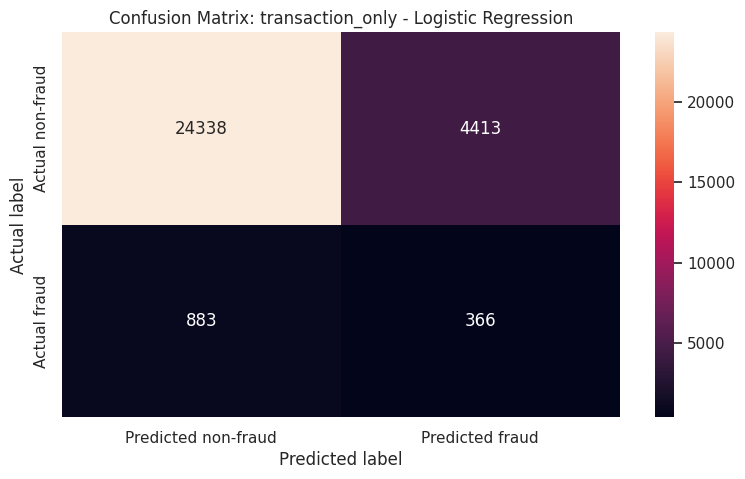

,metric,value
0,true_negatives,24338.0000
1,false_positives,4413.0000
2,false_negatives,883.0000
3,true_positives,366.0000
4,alert_rate,0.1593
5,fraud_capture_rate_recall,0.2930
6,precision_among_flagged_transactions,0.0766


In [34]:
# 12. Select and interpret the final model

model_selection_table = light_tuned_results.copy()

model_selection_table = model_selection_table.sort_values(
    ["validation_PR_AUC", "validation_F1_tuned"],
    ascending=False
).reset_index(drop=True)

final_row = model_selection_table.iloc[0]

FINAL_FEATURE_SET = final_row["feature_set"]
FINAL_MODEL = final_row["model"]
FINAL_CANDIDATE_ID = int(final_row["candidate_id"])
FINAL_THRESHOLD = float(final_row["validation_tuned_threshold"])

print("Final model selected by validation PR-AUC and validation F1:")
display(final_row.to_frame().T)

if FINAL_FEATURE_SET == "transaction_only":
    final_bundle = light_bundle_txn
elif FINAL_FEATURE_SET == "integrated":
    final_bundle = light_bundle_int
else:
    raise ValueError(f"Unexpected feature set: {FINAL_FEATURE_SET}")

final_model_key = f"{FINAL_FEATURE_SET}_{FINAL_MODEL}_{FINAL_CANDIDATE_ID}"

final_model = final_bundle["fitted_candidates"][final_model_key]
X_test_processed = final_bundle["X_test_processed"]
y_test_final = final_bundle["y_test"]

test_probability = get_positive_class_probability(
    final_model,
    X_test_processed
)

test_prediction = (test_probability >= FINAL_THRESHOLD).astype(int)

final_test_metrics = evaluate_binary_classifier(
    y_test_final,
    test_probability,
    threshold=FINAL_THRESHOLD
)

print("\nFinal model:")
print("Feature set:", FINAL_FEATURE_SET)
print("Model:", FINAL_MODEL)
print("Candidate ID:", FINAL_CANDIDATE_ID)
print("Validation-tuned threshold:", round(FINAL_THRESHOLD, 4))
print("Best parameters:", final_row["params"])

print("\nFinal test metrics:")
display(pd.DataFrame([final_test_metrics]))

print("\nFinal test classification report:")
print(classification_report(y_test_final, test_prediction, digits=4))

cm = confusion_matrix(y_test_final, test_prediction)

cm_df = pd.DataFrame(
    cm,
    index=["Actual non-fraud", "Actual fraud"],
    columns=["Predicted non-fraud", "Predicted fraud"]
)

display(cm_df)

sns.heatmap(cm_df, annot=True, fmt="d")
plt.title(f"Confusion Matrix: {FINAL_FEATURE_SET} - {FINAL_MODEL}")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.show()

tn, fp, fn, tp = cm.ravel()

operating_summary = pd.DataFrame([
    {
        "metric": "true_negatives",
        "value": tn
    },
    {
        "metric": "false_positives",
        "value": fp
    },
    {
        "metric": "false_negatives",
        "value": fn
    },
    {
        "metric": "true_positives",
        "value": tp
    },
    {
        "metric": "alert_rate",
        "value": (tp + fp) / len(y_test_final)
    },
    {
        "metric": "fraud_capture_rate_recall",
        "value": tp / (tp + fn) if (tp + fn) > 0 else np.nan
    },
    {
        "metric": "precision_among_flagged_transactions",
        "value": tp / (tp + fp) if (tp + fp) > 0 else np.nan
    }
])

display(operating_summary)

Best integrated model selected by validation PR-AUC and validation F1:


,feature_set,model,candidate_id,validation_PR_AUC,validation_ROC_AUC,validation_tuned_threshold,validation_precision_tuned,validation_recall_tuned,validation_F1_tuned,test_PR_AUC,test_ROC_AUC,test_precision,test_recall,test_F1,params
0,integrated,Logistic Regression,4,0.0709,0.6267,0.5751,0.0795,0.3385,0.1288,0.0695,0.6328,0.0756,0.2962,0.1204,"{'C': 0.3, 'penalty': 'l1'}"



Integrated model test classification report:
              precision    recall  f1-score   support

           0     0.9650    0.8425    0.8996     28751
           1     0.0756    0.2962    0.1204      1249

    accuracy                         0.8198     30000
   macro avg     0.5203    0.5694    0.5100     30000
weighted avg     0.9280    0.8198    0.8672     30000



,Predicted non-fraud,Predicted fraud
Actual non-fraud,24224,4527
Actual fraud,879,370


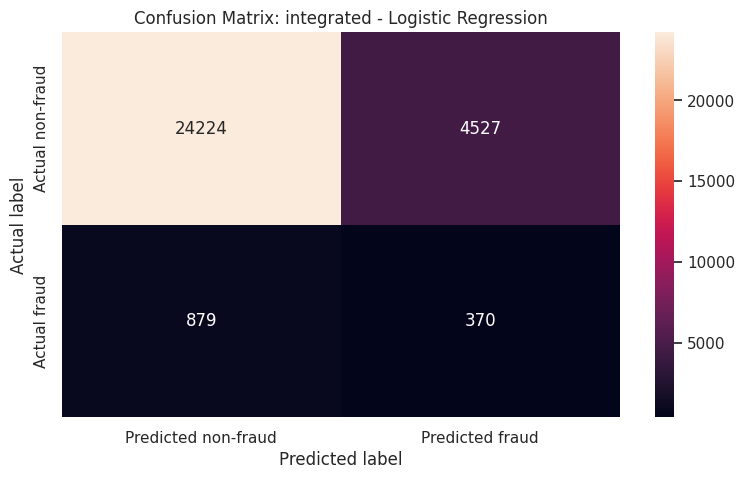

In [35]:
# 12.1 Inspect the best integrated model as a secondary research model

integrated_selection_table = (
    light_tuned_results[light_tuned_results["feature_set"] == "integrated"]
    .sort_values(["validation_PR_AUC", "validation_F1_tuned"], ascending=False)
    .reset_index(drop=True)
)

integrated_row = integrated_selection_table.iloc[0]

INTEGRATED_MODEL = integrated_row["model"]
INTEGRATED_CANDIDATE_ID = int(integrated_row["candidate_id"])
INTEGRATED_THRESHOLD = float(integrated_row["validation_tuned_threshold"])

integrated_model_key = f"integrated_{INTEGRATED_MODEL}_{INTEGRATED_CANDIDATE_ID}"

integrated_model = light_bundle_int["fitted_candidates"][integrated_model_key]
integrated_X_test_processed = light_bundle_int["X_test_processed"]
integrated_y_test = light_bundle_int["y_test"]

integrated_test_probability = get_positive_class_probability(
    integrated_model,
    integrated_X_test_processed
)

integrated_test_prediction = (
    integrated_test_probability >= INTEGRATED_THRESHOLD
).astype(int)

print("Best integrated model selected by validation PR-AUC and validation F1:")
display(integrated_row.to_frame().T)

print("\nIntegrated model test classification report:")
print(classification_report(integrated_y_test, integrated_test_prediction, digits=4))

integrated_cm = confusion_matrix(
    integrated_y_test,
    integrated_test_prediction
)

integrated_cm_df = pd.DataFrame(
    integrated_cm,
    index=["Actual non-fraud", "Actual fraud"],
    columns=["Predicted non-fraud", "Predicted fraud"]
)

display(integrated_cm_df)

sns.heatmap(integrated_cm_df, annot=True, fmt="d")
plt.title(f"Confusion Matrix: integrated - {INTEGRATED_MODEL}")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.show()

Curve diagnostics are based on the final validation-selected model:
Feature set: transaction_only
Model: Logistic Regression
Candidate ID: 4
Validation-tuned threshold: 0.5725


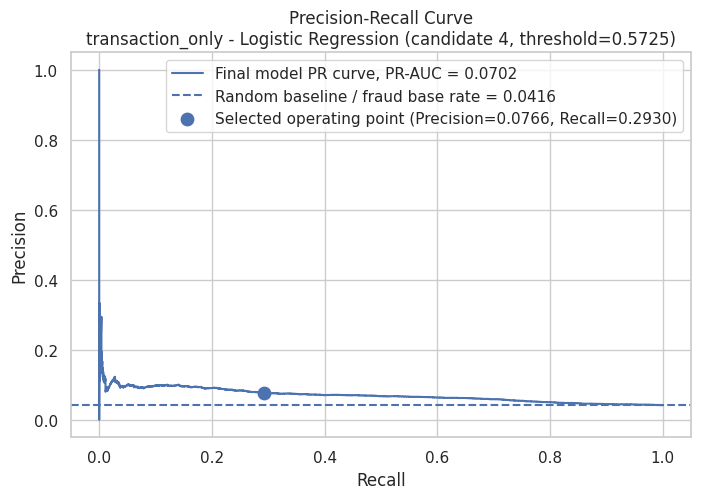

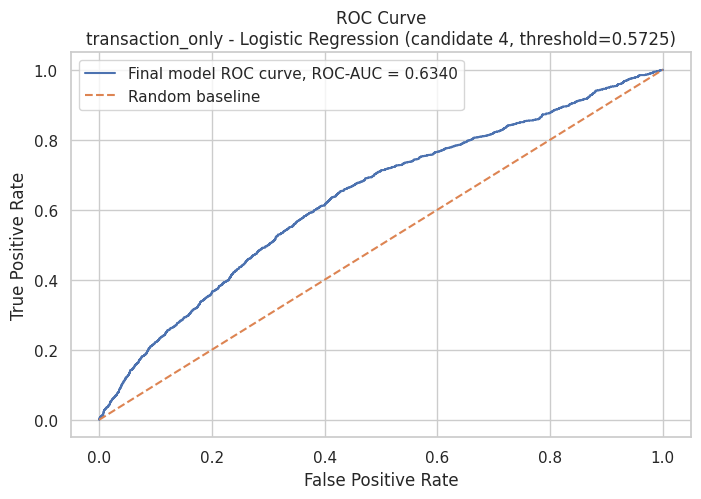

,model_scope,feature_set,model,candidate_id,threshold,test_fraud_rate_baseline,PR_AUC,PR_AUC_lift_over_fraud_base_rate,ROC_AUC,precision_at_threshold,recall_at_threshold,F1_at_threshold
0,final_validation_selected_model,transaction_only,Logistic Regression,4,0.5725,0.0416,0.0702,1.6860,0.6340,0.0766,0.2930,0.1214


In [40]:
# 13. Plot PR and ROC curves for the final validation-selected model

plt.close("all")

final_model_label = (
    f"{FINAL_FEATURE_SET} - {FINAL_MODEL} "
    f"(candidate {FINAL_CANDIDATE_ID}, threshold={FINAL_THRESHOLD:.4f})"
)

print("Curve diagnostics are based on the final validation-selected model:")
print("Feature set:", FINAL_FEATURE_SET)
print("Model:", FINAL_MODEL)
print("Candidate ID:", FINAL_CANDIDATE_ID)
print("Validation-tuned threshold:", round(FINAL_THRESHOLD, 4))

pr_precision, pr_recall, _ = precision_recall_curve(
    y_test_final,
    test_probability
)

final_pr_auc = average_precision_score(
    y_test_final,
    test_probability
)

test_fraud_rate = y_test_final.mean()

final_metrics_at_threshold = evaluate_binary_classifier(
    y_test_final,
    test_probability,
    threshold=FINAL_THRESHOLD
)

plt.figure(figsize=(8, 5))
plt.plot(
    pr_recall,
    pr_precision,
    label=f"Final model PR curve, PR-AUC = {final_pr_auc:.4f}"
)
plt.axhline(
    test_fraud_rate,
    linestyle="--",
    label=f"Random baseline / fraud base rate = {test_fraud_rate:.4f}"
)
plt.scatter(
    final_metrics_at_threshold["Recall"],
    final_metrics_at_threshold["Precision"],
    s=80,
    label=(
        f"Selected operating point "
        f"(Precision={final_metrics_at_threshold['Precision']:.4f}, "
        f"Recall={final_metrics_at_threshold['Recall']:.4f})"
    )
)
plt.title(f"Precision-Recall Curve\n{final_model_label}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

roc_fpr, roc_tpr, _ = roc_curve(
    y_test_final,
    test_probability
)

final_roc_auc = roc_auc_score(
    y_test_final,
    test_probability
)

plt.figure(figsize=(8, 5))
plt.plot(
    roc_fpr,
    roc_tpr,
    label=f"Final model ROC curve, ROC-AUC = {final_roc_auc:.4f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random baseline"
)
plt.title(f"ROC Curve\n{final_model_label}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

curve_summary = pd.DataFrame([
    {
        "model_scope": "final_validation_selected_model",
        "feature_set": FINAL_FEATURE_SET,
        "model": FINAL_MODEL,
        "candidate_id": FINAL_CANDIDATE_ID,
        "threshold": FINAL_THRESHOLD,
        "test_fraud_rate_baseline": test_fraud_rate,
        "PR_AUC": final_pr_auc,
        "PR_AUC_lift_over_fraud_base_rate": final_pr_auc / test_fraud_rate,
        "ROC_AUC": final_roc_auc,
        "precision_at_threshold": final_metrics_at_threshold["Precision"],
        "recall_at_threshold": final_metrics_at_threshold["Recall"],
        "F1_at_threshold": final_metrics_at_threshold["F1"]
    }
])

display(curve_summary)

Feature importance is based on the final validation-selected model:
Feature set: transaction_only
Model: Logistic Regression
Candidate ID: 4
Importance type: linear_coefficients


,feature,coefficient,absolute_coefficient,odds_ratio
0,payment_method_Crypto,0.7710,0.7710,2.1619
1,discount_applied,0.4165,0.4165,1.5166
2,discount_amount,-0.1477,0.1477,0.8627
3,device_type_Mobile,-0.1207,0.1207,0.8863
4,payment_method_PayPal,-0.0818,0.0818,0.9214
5,payment_method_Debit Card,-0.0817,0.0817,0.9215
6,discounted_order_value,0.0801,0.0801,1.0834
7,log_order_value,0.0581,0.0581,1.0598
8,order_dayofweek_sin,-0.0369,0.0369,0.9638
9,order_dayofweek_cos,-0.0348,0.0348,0.9658


Top positive coefficients: features associated with higher predicted fraud risk


,feature,coefficient,absolute_coefficient,odds_ratio
0,payment_method_Crypto,0.7710,0.7710,2.1619
1,discount_applied,0.4165,0.4165,1.5166
6,discounted_order_value,0.0801,0.0801,1.0834
7,log_order_value,0.0581,0.0581,1.0598
12,order_month_sin,0.0191,0.0191,1.0193
16,order_month_cos,0.0089,0.0089,1.0089
17,order_quarter,0.0018,0.0018,1.0018
18,order_month,0.0011,0.0011,1.0011
19,order_value,0.0000,0.0000,1.0000
20,device_type_Desktop,0.0000,0.0000,1.0000


Top negative coefficients: features associated with lower predicted fraud risk


,feature,coefficient,absolute_coefficient,odds_ratio
2,discount_amount,-0.1477,0.1477,0.8627
3,device_type_Mobile,-0.1207,0.1207,0.8863
4,payment_method_PayPal,-0.0818,0.0818,0.9214
5,payment_method_Debit Card,-0.0817,0.0817,0.9215
8,order_dayofweek_sin,-0.0369,0.0369,0.9638
9,order_dayofweek_cos,-0.0348,0.0348,0.9658
10,device_type_Tablet,-0.0212,0.0212,0.9790
11,is_weekend_order,-0.0192,0.0192,0.9809
13,order_dayofweek,-0.0174,0.0174,0.9828
14,order_year,-0.0160,0.0160,0.9841


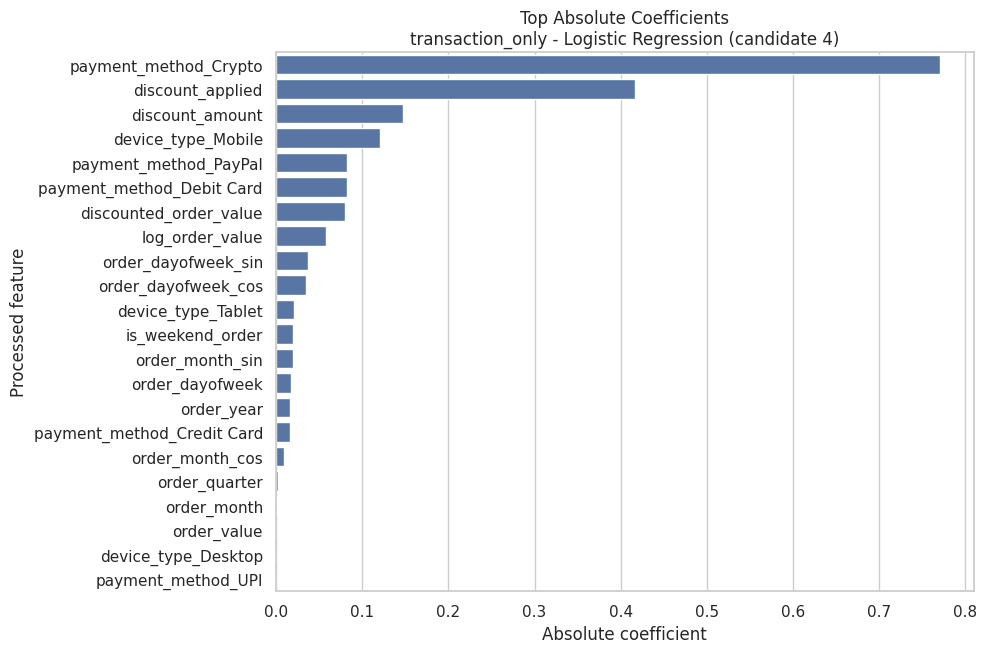

In [41]:
# 14. Interpret final model feature importance

def clean_processed_feature_name(feature_name):
    """Clean feature names generated by ColumnTransformer."""
    feature_name = str(feature_name)
    feature_name = feature_name.replace("numeric__", "")
    feature_name = feature_name.replace("categorical__", "")
    feature_name = feature_name.replace("onehot__", "")
    return feature_name

def get_processed_feature_names(preprocessor, n_features):
    """Get processed feature names after preprocessing."""
    try:
        feature_names = preprocessor.get_feature_names_out()
        feature_names = [clean_processed_feature_name(name) for name in feature_names]
    except Exception:
        feature_names = [f"processed_feature_{i}" for i in range(n_features)]

    return np.array(feature_names)

def get_final_model_feature_importance(model, feature_names):
    """Extract feature importance for linear or tree-based models."""
    if hasattr(model, "coef_"):
        coefficients = model.coef_[0]

        feature_importance = pd.DataFrame({
            "feature": feature_names,
            "coefficient": coefficients,
            "absolute_coefficient": np.abs(coefficients),
            "odds_ratio": np.exp(coefficients)
        })

        feature_importance = feature_importance.sort_values(
            "absolute_coefficient",
            ascending=False
        ).reset_index(drop=True)

        return feature_importance, "linear_coefficients"

    if hasattr(model, "feature_importances_"):
        feature_importance = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_
        })

        feature_importance = feature_importance.sort_values(
            "importance",
            ascending=False
        ).reset_index(drop=True)

        return feature_importance, "tree_importance"

    return None, None

processed_feature_names = get_processed_feature_names(
    final_bundle["preprocessor"],
    final_bundle["X_train_processed"].shape[1]
)

feature_importance, importance_type = get_final_model_feature_importance(
    final_model,
    processed_feature_names
)

print("Feature importance is based on the final validation-selected model:")
print("Feature set:", FINAL_FEATURE_SET)
print("Model:", FINAL_MODEL)
print("Candidate ID:", FINAL_CANDIDATE_ID)
print("Importance type:", importance_type)

if feature_importance is not None:
    display(feature_importance.head(30))

    if importance_type == "linear_coefficients":
        top_positive_features = (
            feature_importance
            .sort_values("coefficient", ascending=False)
            .head(15)
        )

        top_negative_features = (
            feature_importance
            .sort_values("coefficient", ascending=True)
            .head(15)
        )

        print("Top positive coefficients: features associated with higher predicted fraud risk")
        display(top_positive_features)

        print("Top negative coefficients: features associated with lower predicted fraud risk")
        display(top_negative_features)

        top_abs_features = feature_importance.head(25)

        plt.figure(figsize=(9, 7))
        sns.barplot(
            data=top_abs_features,
            x="absolute_coefficient",
            y="feature"
        )
        plt.title(
            f"Top Absolute Coefficients\n{FINAL_FEATURE_SET} - {FINAL_MODEL} "
            f"(candidate {FINAL_CANDIDATE_ID})"
        )
        plt.xlabel("Absolute coefficient")
        plt.ylabel("Processed feature")
        plt.show()

    elif importance_type == "tree_importance":
        top_features = feature_importance.head(25)

        plt.figure(figsize=(9, 7))
        sns.barplot(
            data=top_features,
            x="importance",
            y="feature"
        )
        plt.title(
            f"Top Feature Importances\n{FINAL_FEATURE_SET} - {FINAL_MODEL} "
            f"(candidate {FINAL_CANDIDATE_ID})"
        )
        plt.xlabel("Feature importance")
        plt.ylabel("Processed feature")
        plt.show()
else:
    print("No native feature importance is available for the final model.")

In [42]:
# 14.1 Display non-zero coefficients from the final L1-regularized model

nonzero_feature_importance = (
    feature_importance[feature_importance["absolute_coefficient"] > 1e-6]
    .copy()
    .sort_values("absolute_coefficient", ascending=False)
)

display(nonzero_feature_importance)

,feature,coefficient,absolute_coefficient,odds_ratio
0,payment_method_Crypto,0.7710,0.7710,2.1619
1,discount_applied,0.4165,0.4165,1.5166
2,discount_amount,-0.1477,0.1477,0.8627
3,device_type_Mobile,-0.1207,0.1207,0.8863
4,payment_method_PayPal,-0.0818,0.0818,0.9214
5,payment_method_Debit Card,-0.0817,0.0817,0.9215
6,discounted_order_value,0.0801,0.0801,1.0834
7,log_order_value,0.0581,0.0581,1.0598
8,order_dayofweek_sin,-0.0369,0.0369,0.9638
9,order_dayofweek_cos,-0.0348,0.0348,0.9658


SHAP analysis is based on the best validation-selected integrated tree model:
Feature set: integrated
Model: LightGBM
Candidate ID: 7
Validation PR-AUC: 0.0634
Test PR-AUC: 0.0623
Model parameters: {'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 100, 'reg_lambda': 5.0}


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


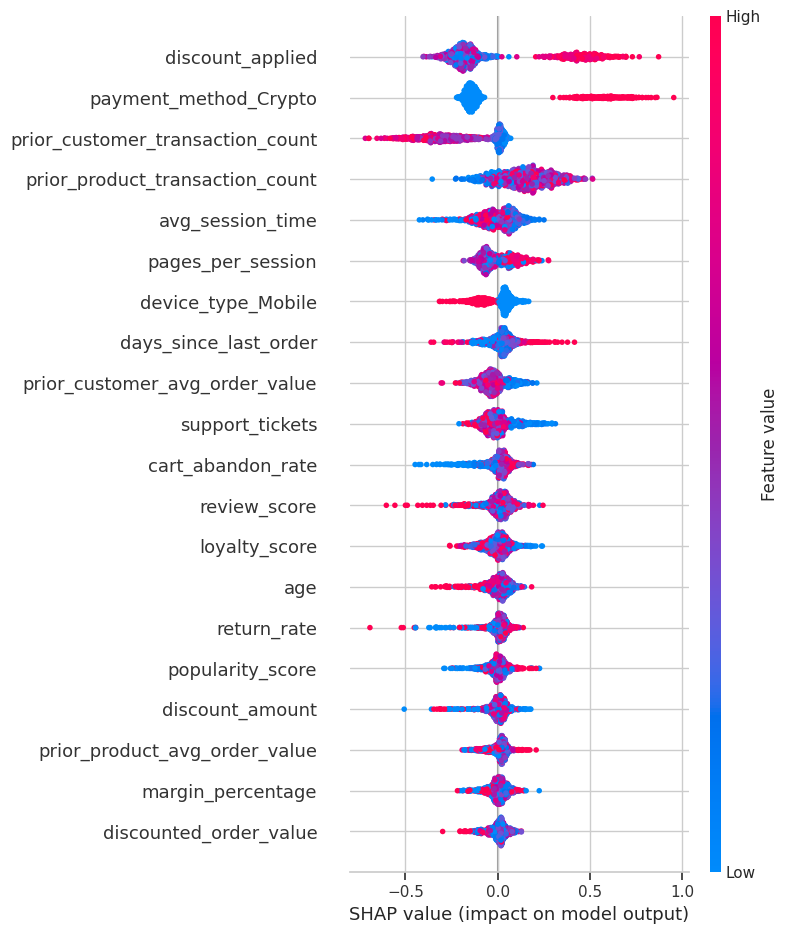

,feature,mean_absolute_shap_value
0,discount_applied,0.2591
1,payment_method_Crypto,0.2385
2,prior_customer_transaction_count,0.1980
3,prior_product_transaction_count,0.1661
4,avg_session_time,0.0749
5,pages_per_session,0.0718
6,device_type_Mobile,0.0657
7,days_since_last_order,0.0571
8,prior_customer_avg_order_value,0.0571
9,support_tickets,0.0559


In [43]:
# 15. SHAP explainability for the best integrated tree-based model

import shap

tree_model_names = ["LightGBM", "XGBoost", "Random Forest"]

integrated_tree_candidates = (
    light_tuned_results[
        (light_tuned_results["feature_set"] == "integrated") &
        (light_tuned_results["model"].isin(tree_model_names))
    ]
    .sort_values(["validation_PR_AUC", "validation_F1_tuned"], ascending=False)
    .reset_index(drop=True)
)

if integrated_tree_candidates.empty:
    print("No integrated tree-based model is available for SHAP analysis.")
else:
    shap_row = integrated_tree_candidates.iloc[0]

    SHAP_MODEL_NAME = shap_row["model"]
    SHAP_CANDIDATE_ID = int(shap_row["candidate_id"])
    SHAP_MODEL_KEY = f"integrated_{SHAP_MODEL_NAME}_{SHAP_CANDIDATE_ID}"

    shap_model = light_bundle_int["fitted_candidates"][SHAP_MODEL_KEY]
    shap_X_test = light_bundle_int["X_test_processed"]

    shap_feature_names = get_processed_feature_names(
        light_bundle_int["preprocessor"],
        shap_X_test.shape[1]
    )

    print("SHAP analysis is based on the best validation-selected integrated tree model:")
    print("Feature set: integrated")
    print("Model:", SHAP_MODEL_NAME)
    print("Candidate ID:", SHAP_CANDIDATE_ID)
    print("Validation PR-AUC:", round(shap_row["validation_PR_AUC"], 4))
    print("Test PR-AUC:", round(shap_row["test_PR_AUC"], 4))
    print("Model parameters:", shap_row["params"])

    shap_sample_size = min(1000, shap_X_test.shape[0])
    rng = np.random.default_rng(analysis_random_state)
    shap_sample_indices = rng.choice(
        shap_X_test.shape[0],
        size=shap_sample_size,
        replace=False
    )

    shap_X_sample = shap_X_test[shap_sample_indices]

    try:
        explainer = shap.TreeExplainer(shap_model)
        shap_values = explainer.shap_values(shap_X_sample)

        if isinstance(shap_values, list):
            shap_values_for_plot = shap_values[1]
        else:
            shap_values_for_plot = shap_values

        if len(np.array(shap_values_for_plot).shape) == 3:
            shap_values_for_plot = shap_values_for_plot[:, :, 1]

        shap.summary_plot(
            shap_values_for_plot,
            shap_X_sample,
            feature_names=shap_feature_names,
            max_display=20,
            show=True
        )

        mean_abs_shap = np.abs(shap_values_for_plot).mean(axis=0)

        shap_importance = (
            pd.DataFrame({
                "feature": shap_feature_names,
                "mean_absolute_shap_value": mean_abs_shap
            })
            .sort_values("mean_absolute_shap_value", ascending=False)
            .reset_index(drop=True)
        )

        display(shap_importance.head(30))

    except Exception as error:
        print("SHAP analysis failed:", error)

In [44]:
# 16. Review high-risk transactions from the final validation-selected model

test_view = df.iloc[idx_test].copy().reset_index(drop=True)

test_view["fraud_probability"] = test_probability
test_view["predicted_fraud"] = test_prediction
test_view["final_model_threshold"] = FINAL_THRESHOLD

def assign_operating_outcome(row):
    """Label each transaction by prediction outcome for retrospective evaluation."""
    if row["fraud_label"] == 1 and row["predicted_fraud"] == 1:
        return "true_positive"
    if row["fraud_label"] == 0 and row["predicted_fraud"] == 1:
        return "false_positive"
    if row["fraud_label"] == 1 and row["predicted_fraud"] == 0:
        return "false_negative"
    return "true_negative"

test_view["operating_outcome"] = test_view.apply(assign_operating_outcome, axis=1)

review_columns = [
    "transaction_id",
    "customer_id",
    "product_id",
    "order_date",
    "order_value",
    "discount_applied",
    "discounted_order_value",
    "discount_amount",
    "log_order_value",
    "payment_method",
    "device_type",
    "category",
    "price",
    "margin_percentage",
    "popularity_score",
    "age",
    "gender",
    "country",
    "loyalty_score",
    "avg_session_time",
    "pages_per_session",
    "cart_abandon_rate",
    "return_rate",
    "support_tickets",
    "review_score",
    "prior_customer_transaction_count",
    "prior_customer_avg_order_value",
    "days_since_last_order",
    "prior_product_transaction_count",
    "prior_product_avg_order_value",
    "fraud_probability",
    "final_model_threshold",
    "predicted_fraud",
    "fraud_label",
    "operating_outcome"
]

review_columns = [
    col for col in review_columns
    if col in test_view.columns
]

high_risk_transactions = (
    test_view[review_columns]
    .sort_values("fraud_probability", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

print("Top 30 high-risk transactions based on final model probability:")
display(high_risk_transactions)

Top 30 high-risk transactions based on final model probability:


,transaction_id,customer_id,product_id,order_date,order_value,discount_applied,discounted_order_value,discount_amount,log_order_value,payment_method,device_type,category,price,margin_percentage,popularity_score,age,gender,country,loyalty_score,avg_session_time,pages_per_session,cart_abandon_rate,return_rate,support_tickets,review_score,prior_customer_transaction_count,prior_customer_avg_order_value,days_since_last_order,prior_product_transaction_count,prior_product_avg_order_value,fraud_probability,final_model_threshold,predicted_fraud,fraud_label,operating_outcome
0,TXN0147132,CUST012437,PROD00526,2023-12-29,52.1200,0.4800,27.1024,25.0176,3.9726,Crypto,Desktop,Sports,100.2400,5.8300,64.2000,37,Female,Canada,8.9600,7.0600,3,0.2100,0.2000,6,3.8000,9,387.0700,243.0000,78,71.7745,0.7741,0.5725,1,0,false_positive
1,TXN0079916,CUST023680,PROD00887,2023-10-13,110.1200,0.4900,56.1612,53.9588,4.7106,Crypto,Desktop,Fashion,215.9300,28.0100,47.2300,44,Male,USA,84.1800,7.0100,20,0.5200,0.4700,10,3.5100,4,562.6825,317.0000,57,166.4930,0.7725,0.5725,1,0,false_positive
2,TXN0044126,CUST009886,PROD01753,2024-03-22,37.4400,0.4900,19.0944,18.3456,3.6491,Crypto,Tablet,Toys,73.4100,24.2400,41.7200,62,Other,Australia,87.9800,2.6900,2,0.0400,0.4300,4,2.2500,7,389.2343,166.0000,82,54.4310,0.7721,0.5725,1,1,true_positive
3,TXN0038256,CUST017396,PROD01380,2024-01-26,163.4600,0.5000,81.7300,81.7300,5.1027,Crypto,Tablet,Automotive,326.9100,28.2800,55.6600,55,Other,France,48.9500,12.1200,18,0.6100,0.4400,5,3.7200,7,467.3357,718.0000,70,245.4160,0.7718,0.5725,1,0,false_positive
4,TXN0109900,CUST012269,PROD00600,2023-07-28,38.3600,0.5000,19.1800,19.1800,3.6728,Crypto,Tablet,Electronics,76.7200,7.4900,1.2100,26,Other,Brazil,43.6300,3.8000,9,0.4000,0.1600,3,1.8100,6,371.9283,80.0000,55,59.5487,0.7718,0.5725,1,0,false_positive
5,TXN0129375,CUST017603,PROD00953,2024-01-19,116.8700,0.4800,60.7724,56.0976,4.7696,Crypto,Desktop,Books,224.7500,6.3600,3.6000,24,Female,Canada,7.8300,16.4600,1,0.2400,0.2400,5,3.9900,3,529.2600,497.0000,84,169.5529,0.7706,0.5725,1,0,false_positive
6,TXN0083333,CUST003311,PROD00902,2024-04-12,10.9300,0.5000,5.4650,5.4650,2.4791,Crypto,Desktop,Beauty,21.8600,31.9600,80.7200,47,Female,Australia,11.3200,5.4600,22,0.1000,0.0700,7,3.8100,5,218.9020,144.0000,55,16.2044,0.7705,0.5725,1,0,false_positive
7,TXN0087287,CUST003876,PROD00075,2023-10-20,50.0900,0.4900,25.5459,24.5441,3.9336,Crypto,Tablet,Fashion,98.2100,17.8700,26.5200,60,Male,Australia,15.8300,19.2500,24,0.6900,0.1800,5,4.7500,8,507.0825,132.0000,58,76.6724,0.7698,0.5725,1,0,false_positive
8,TXN0066576,CUST019130,PROD01364,2023-09-15,25.3800,0.4900,12.9438,12.4362,3.2726,Crypto,Desktop,Electronics,49.7700,30.7000,34.1300,50,Other,USA,95.3000,17.9100,3,0.5000,0.2900,10,2.8200,2,66.7750,415.0000,76,37.4850,0.7679,0.5725,1,0,false_positive
9,TXN0109991,CUST019445,PROD00552,2024-01-18,181.6700,0.5000,90.8350,90.8350,5.2077,Crypto,Desktop,Toys,363.3400,8.0700,93.7000,26,Male,USA,31.0000,10.4700,25,0.3300,0.1300,3,2.7400,6,291.4100,29.0000,70,262.0193,0.7672,0.5725,1,1,true_positive


In [47]:
# 16.1 Summarize high-risk review outcomes

top_n_values = [30, 100, 500, 1000]
test_fraud_rate = test_view["fraud_label"].mean()

high_risk_review_summary = []

for top_n in top_n_values:
    top_subset = (
        test_view
        .sort_values("fraud_probability", ascending=False)
        .head(top_n)
    )

    review_precision = top_subset["fraud_label"].mean()

    high_risk_review_summary.append({
        "top_n_reviewed": top_n,
        "fraud_cases_found": int(top_subset["fraud_label"].sum()),
        "review_precision": review_precision,
        "precision_lift_over_test_base_rate": review_precision / test_fraud_rate,
        "share_of_all_test_fraud_captured": top_subset["fraud_label"].sum() / test_view["fraud_label"].sum(),
        "mean_predicted_probability": top_subset["fraud_probability"].mean()
    })

high_risk_review_summary = pd.DataFrame(high_risk_review_summary)

display(high_risk_review_summary)

,top_n_reviewed,fraud_cases_found,review_precision,precision_lift_over_test_base_rate,share_of_all_test_fraud_captured,mean_predicted_probability
0,30,5,0.1667,4.0032,0.0040,0.7655
1,100,12,0.1200,2.8823,0.0096,0.7567
2,500,47,0.0940,2.2578,0.0376,0.7367
3,1000,92,0.0920,2.2098,0.0737,0.7216


In [46]:
# 16.2 Summarize all transactions flagged by the final threshold

flagged_transactions = test_view[test_view["predicted_fraud"] == 1].copy()

flagged_summary = pd.DataFrame([
    {
        "metric": "number_of_flagged_transactions",
        "value": len(flagged_transactions)
    },
    {
        "metric": "flagged_transaction_rate",
        "value": len(flagged_transactions) / len(test_view)
    },
    {
        "metric": "fraud_cases_among_flagged",
        "value": int(flagged_transactions["fraud_label"].sum())
    },
    {
        "metric": "precision_among_flagged",
        "value": flagged_transactions["fraud_label"].mean()
    },
    {
        "metric": "share_of_all_test_fraud_captured",
        "value": flagged_transactions["fraud_label"].sum() / test_view["fraud_label"].sum()
    }
])

display(flagged_summary)

,metric,value
0,number_of_flagged_transactions,4779.0000
1,flagged_transaction_rate,0.1593
2,fraud_cases_among_flagged,366.0000
3,precision_among_flagged,0.0766
4,share_of_all_test_fraud_captured,0.2930


In [49]:
# 17. Create an LLM risk-report prompt for analyst decision support

def fmt_value(value, decimals=2):
    """Format numeric values for analyst-facing text."""
    if pd.isna(value):
        return "NA"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)):
        return f"{value:.{decimals}f}"
    return str(value)

def fmt_percent(value, decimals=2):
    """Format decimal rates as percentages."""
    if pd.isna(value):
        return "NA"
    return f"{100 * float(value):.{decimals}f}%"

def fmt_date(value):
    """Format datetime values as dates."""
    if pd.isna(value):
        return "NA"
    try:
        return pd.to_datetime(value).strftime("%Y-%m-%d")
    except Exception:
        return str(value)

def assign_prompt_risk_level(score, threshold):
    """Assign a simple risk level based on the final model score and operating threshold."""
    if score >= threshold:
        return "High"
    if score >= 0.5 * threshold:
        return "Medium"
    return "Low"

def make_llm_prompt(row, score, threshold):
    """Create a structured analyst-facing LLM prompt for a transaction risk report."""
    predicted_flag = int(score >= threshold)
    suggested_risk_level = assign_prompt_risk_level(score, threshold)

    prompt = f"""
You are assisting a fraud-risk analyst for an enterprise e-commerce platform.

Task:
Write a concise, human-readable transaction risk report based only on the structured information below. Do not claim that the transaction is definitely fraudulent. Treat the model output as decision support, not as a final decision.

Model output:
- Fraud risk score: {score:.4f}
- Operating threshold: {threshold:.4f}
- Predicted fraud flag: {predicted_flag}
- Suggested risk level from model score: {suggested_risk_level}

Transaction context:
- transaction_id: {row.get("transaction_id", "NA")}
- customer_id: {row.get("customer_id", "NA")}
- product_id: {row.get("product_id", "NA")}
- order_date: {fmt_date(row.get("order_date", "NA"))}
- order_value: {fmt_value(row.get("order_value", np.nan))}
- discount_applied: {fmt_percent(row.get("discount_applied", np.nan))}
- discounted_order_value: {fmt_value(row.get("discounted_order_value", np.nan))}
- discount_amount: {fmt_value(row.get("discount_amount", np.nan))}
- payment_method: {row.get("payment_method", "NA")}
- device_type: {row.get("device_type", "NA")}

Product and behavioral context for analyst review:
- category: {row.get("category", "NA")}
- price: {fmt_value(row.get("price", np.nan))}
- margin_percentage: {fmt_percent(row.get("margin_percentage", np.nan) / 100 if pd.notna(row.get("margin_percentage", np.nan)) else np.nan)}
- popularity_score: {fmt_value(row.get("popularity_score", np.nan))}
- loyalty_score: {fmt_value(row.get("loyalty_score", np.nan))}
- avg_session_time: {fmt_value(row.get("avg_session_time", np.nan))}
- pages_per_session: {fmt_value(row.get("pages_per_session", np.nan))}
- cart_abandon_rate: {fmt_percent(row.get("cart_abandon_rate", np.nan))}
- return_rate: {fmt_percent(row.get("return_rate", np.nan))}
- support_tickets: {fmt_value(row.get("support_tickets", np.nan))}
- review_score: {fmt_value(row.get("review_score", np.nan))}

Prior-history context:
- prior_customer_transaction_count: {fmt_value(row.get("prior_customer_transaction_count", np.nan))}
- prior_customer_avg_order_value: {fmt_value(row.get("prior_customer_avg_order_value", np.nan))}
- days_since_last_order: {fmt_value(row.get("days_since_last_order", np.nan))}
- prior_product_transaction_count: {fmt_value(row.get("prior_product_transaction_count", np.nan))}
- prior_product_avg_order_value: {fmt_value(row.get("prior_product_avg_order_value", np.nan))}

Important instructions:
- Do not use protected or demographic attributes as risk justifications.
- Do not mention the true fraud label, even if it exists in the dataset.
- Focus on transaction-level, payment, discount, product, and behavioral risk signals.
- Include alternative benign explanations where appropriate.
- Recommend analyst review actions, not automatic rejection.

Output format:
1. Risk level: Low / Medium / High
2. Main risk signals
3. Alternative benign explanations
4. Recommended analyst action
5. One-sentence business summary
"""
    return prompt.strip()

sample_case = high_risk_transactions.iloc[0]

sample_prompt = make_llm_prompt(
    row=sample_case,
    score=sample_case["fraud_probability"],
    threshold=FINAL_THRESHOLD
)

print("Sample LLM prompt:")
print(sample_prompt)

Sample LLM prompt:
You are assisting a fraud-risk analyst for an enterprise e-commerce platform.

Task:
Write a concise, human-readable transaction risk report based only on the structured information below. Do not claim that the transaction is definitely fraudulent. Treat the model output as decision support, not as a final decision.

Model output:
- Fraud risk score: 0.7741
- Operating threshold: 0.5725
- Predicted fraud flag: 1
- Suggested risk level from model score: High

Transaction context:
- transaction_id: TXN0147132
- customer_id: CUST012437
- product_id: PROD00526
- order_date: 2023-12-29
- order_value: 52.12
- discount_applied: 48.00%
- discounted_order_value: 27.10
- discount_amount: 25.02
- payment_method: Crypto
- device_type: Desktop

Product and behavioral context for analyst review:
- category: Sports
- price: 100.24
- margin_percentage: 5.83%
- popularity_score: 64.20
- loyalty_score: 8.96
- avg_session_time: 7.06
- pages_per_session: 3
- cart_abandon_rate: 21.00%
- 

In [50]:
# 18. Save final outputs and model artifacts

OUT_DIR = Path("/content/fd_final_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_if_exists(object_name, filename):
    """Save a DataFrame if it exists in the current notebook environment."""
    if object_name in globals():
        obj = globals()[object_name]
        if isinstance(obj, pd.DataFrame):
            obj.to_csv(OUT_DIR / filename, index=False)
            print(f"Saved {filename}")
        else:
            print(f"Skipped {filename}: {object_name} exists but is not a DataFrame.")
    else:
        print(f"Skipped {filename}: {object_name} is not defined.")

save_if_exists("results_all", "fd_initial_model_metrics.csv")
save_if_exists("tuned_results", "fd_initial_tuned_results.csv")
save_if_exists("best_by_feature_set", "fd_initial_best_by_feature_set.csv")
save_if_exists("comparison_summary", "fd_initial_feature_set_comparison.csv")

save_if_exists("light_tuned_results", "fd_lightweight_tuned_results.csv")
save_if_exists("best_light_tuned_by_feature_set", "fd_lightweight_best_by_feature_set.csv")
save_if_exists("light_tuned_comparison_summary", "fd_lightweight_feature_set_comparison.csv")
save_if_exists("light_tuned_baseline_lift", "fd_pr_auc_baseline_lift.csv")

save_if_exists("validation_selected_by_feature_set", "fd_validation_selected_by_feature_set.csv")
save_if_exists("research_question_comparison", "fd_research_question_comparison.csv")

save_if_exists("curve_summary", "fd_final_curve_summary.csv")
save_if_exists("operating_summary", "fd_final_operating_summary.csv")
save_if_exists("cm_df", "fd_final_confusion_matrix.csv")

save_if_exists("high_risk_transactions", "fd_high_risk_transactions_top30.csv")
save_if_exists("high_risk_review_summary", "fd_high_risk_review_summary.csv")
save_if_exists("flagged_summary", "fd_flagged_transaction_summary.csv")

save_if_exists("feature_importance", "fd_final_feature_importance_all.csv")
save_if_exists("nonzero_feature_importance", "fd_final_feature_importance_nonzero.csv")
save_if_exists("shap_importance", "fd_integrated_tree_shap_importance.csv")

with open(OUT_DIR / "fd_sample_llm_prompt.txt", "w", encoding="utf-8") as f:
    if "sample_prompt" in globals():
        f.write(sample_prompt)
        print("Saved fd_sample_llm_prompt.txt")
    else:
        f.write("sample_prompt was not defined.")
        print("Saved fd_sample_llm_prompt.txt with placeholder text.")

final_model_artifact = {
    "model_scope": "final_validation_selected_model",
    "feature_set": FINAL_FEATURE_SET,
    "model_name": FINAL_MODEL,
    "candidate_id": FINAL_CANDIDATE_ID,
    "threshold": FINAL_THRESHOLD,
    "best_params": final_row["params"],
    "model": final_model,
    "preprocessor": final_bundle["preprocessor"],
    "raw_features": final_bundle.get("feature_list", None),
    "numeric_features": (
        txn_numeric_features if FINAL_FEATURE_SET == "transaction_only"
        else int_numeric_features
    ),
    "categorical_features": (
        txn_categorical_features if FINAL_FEATURE_SET == "transaction_only"
        else int_categorical_features
    ),
    "excluded_features": excluded_features,
    "leakage_risk_features": leakage_risk_features,
    "identifier_and_date_features": identifier_and_date_features,
    "diagnostic_only_features": diagnostic_only_features,
    "target": TARGET,
    "random_state": analysis_random_state
}

joblib.dump(
    final_model_artifact,
    OUT_DIR / "fd_final_model_bundle.joblib"
)

print("Saved fd_final_model_bundle.joblib")
print("\nSaved final outputs to:", OUT_DIR)
print("Saved files:")
for file_path in sorted(OUT_DIR.iterdir()):
    print("-", file_path.name)

Saved fd_initial_model_metrics.csv
Saved fd_initial_tuned_results.csv
Saved fd_initial_best_by_feature_set.csv
Saved fd_initial_feature_set_comparison.csv
Saved fd_lightweight_tuned_results.csv
Saved fd_lightweight_best_by_feature_set.csv
Saved fd_lightweight_feature_set_comparison.csv
Saved fd_pr_auc_baseline_lift.csv
Saved fd_validation_selected_by_feature_set.csv
Saved fd_research_question_comparison.csv
Saved fd_final_curve_summary.csv
Saved fd_final_operating_summary.csv
Saved fd_final_confusion_matrix.csv
Saved fd_high_risk_transactions_top30.csv
Saved fd_high_risk_review_summary.csv
Saved fd_flagged_transaction_summary.csv
Saved fd_final_feature_importance_all.csv
Saved fd_final_feature_importance_nonzero.csv
Saved fd_integrated_tree_shap_importance.csv
Saved fd_sample_llm_prompt.txt
Saved fd_final_model_bundle.joblib

Saved final outputs to: /content/fd_final_outputs
Saved files:
- fd_final_confusion_matrix.csv
- fd_final_curve_summary.csv
- fd_final_feature_importance_all.csv


In [51]:
# 19. Zip final outputs for download

import shutil

zip_path = shutil.make_archive(
    "/content/fd_final_outputs",
    "zip",
    "/content/fd_final_outputs"
)

print("Zipped output file:", zip_path)

Zipped output file: /content/fd_final_outputs.zip


In [52]:
# 20. Final report-ready summary

final_metrics_for_summary = evaluate_binary_classifier(
    y_test_final,
    test_probability,
    threshold=FINAL_THRESHOLD
)

test_fraud_rate = y_test_final.mean()
pr_auc_lift = final_metrics_for_summary["PR_AUC"] / test_fraud_rate

cm_final = confusion_matrix(y_test_final, test_prediction)
tn, fp, fn, tp = cm_final.ravel()

alert_rate = (tp + fp) / len(y_test_final)
fraud_capture_rate = tp / (tp + fn) if (tp + fn) > 0 else np.nan
precision_among_flagged = tp / (tp + fp) if (tp + fp) > 0 else np.nan

print("\n" + "=" * 90)
print("FINAL REPORT-READY SUMMARY")
print("=" * 90)

print("\nDataset and target:")
print(f"- Dataset size after merge: {df.shape[0]:,} transactions")
print(f"- Number of final modeling features in transaction-only set: {len(transaction_only_features)}")
print(f"- Number of final modeling features in integrated set: {len(integrated_features)}")
print(f"- Overall fraud rate: {df[TARGET].mean():.4%}")
print(f"- Test-set fraud rate: {test_fraud_rate:.4%}")

print("\nFinal validation-selected model:")
print(f"- Feature set: {FINAL_FEATURE_SET}")
print(f"- Model: {FINAL_MODEL}")
print(f"- Candidate ID: {FINAL_CANDIDATE_ID}")
print(f"- Final threshold: {FINAL_THRESHOLD:.4f}")
print(f"- Best parameters: {final_row['params']}")

print("\nFinal test performance:")
print(f"- PR-AUC: {final_metrics_for_summary['PR_AUC']:.4f}")
print(f"- PR-AUC lift over test fraud base rate: {pr_auc_lift:.4f}")
print(f"- ROC-AUC: {final_metrics_for_summary['ROC_AUC']:.4f}")
print(f"- Precision: {final_metrics_for_summary['Precision']:.4f}")
print(f"- Recall: {final_metrics_for_summary['Recall']:.4f}")
print(f"- F1-score: {final_metrics_for_summary['F1']:.4f}")

print("\nFinal operating-point interpretation:")
print(f"- True positives: {tp:,}")
print(f"- False positives: {fp:,}")
print(f"- False negatives: {fn:,}")
print(f"- True negatives: {tn:,}")
print(f"- Alert rate: {alert_rate:.4%}")
print(f"- Fraud capture rate / recall: {fraud_capture_rate:.4%}")
print(f"- Precision among flagged transactions: {precision_among_flagged:.4%}")

print("\nResearch question finding:")
print(
    "- Integrated multi-source features did not improve overall PR-AUC or F1-score "
    "relative to the transaction-only baseline."
)
print(
    "- The integrated feature set produced only a very small recall gain, suggesting "
    "limited incremental value in this synthetic dataset."
)

print("\nMain interpretation:")
print(
    "- The strongest and most stable fraud signals were transaction-level variables, "
    "especially cryptocurrency payment and discount-related features."
)
print(
    "- The final model is best interpreted as a fraud-risk screening and prioritization "
    "tool rather than as a standalone automated decision system."
)

print("\nMethod note:")
print(
    "- Leakage-risk variables were excluded, including shipping_delay_days, "
    "lifetime_value, churn_label, and behavior_churn_signal."
)
print(
    "- Customer-tenure-derived variables were treated as diagnostic-only because a large "
    "share of transactions had registration dates later than order dates."
)
print(
    "- A chronological train-validation-test split was used to approximate future-transaction prediction."
)
print(
    "- PR-AUC, precision, recall, and F1-score were prioritized because fraud detection is highly imbalanced."
)


FINAL REPORT-READY SUMMARY

Dataset and target:
- Dataset size after merge: 150,000 transactions
- Number of final modeling features in transaction-only set: 16
- Number of final modeling features in integrated set: 39
- Overall fraud rate: 4.2207%
- Test-set fraud rate: 4.1633%

Final validation-selected model:
- Feature set: transaction_only
- Model: Logistic Regression
- Candidate ID: 4
- Final threshold: 0.5725
- Best parameters: {'C': 0.3, 'penalty': 'l1'}

Final test performance:
- PR-AUC: 0.0702
- PR-AUC lift over test fraud base rate: 1.6860
- ROC-AUC: 0.6340
- Precision: 0.0766
- Recall: 0.2930
- F1-score: 0.1214

Final operating-point interpretation:
- True positives: 366
- False positives: 4,413
- False negatives: 883
- True negatives: 24,338
- Alert rate: 15.9300%
- Fraud capture rate / recall: 29.3034%
- Precision among flagged transactions: 7.6585%

Research question finding:
- Integrated multi-source features did not improve overall PR-AUC or F1-score relative to the tr